# Agentic AI-Based Dynamic Tariff Optimization for EV Charging Networks
### Open Project 2026 — Society of Business | Submission Notebook

---

**Name:** Arun Kaarthikeyan R  
**Enrollment No:** 23321006  
**Branch:** BS Chemical Sciences

---

## Overview

This notebook builds an end-to-end **Agentic AI framework** using real-world EV charging session data to autonomously predict demand, optimize dynamic tariffs, and continuously refine pricing decisions through a feedback loop.

### Agents
| Agent | Role |
|---|---|
| **Demand Prediction Agent** | Forecasts charging demand and station utilization across time and location |
| **Tariff Pricing Agent** | Translates demand forecasts into optimal per-kWh dynamic tariffs |
| **Monitoring & Learning Agent** | Evaluates pricing outcomes and feeds improvements back into the system |

### Datasets
| Dataset | Coverage | Format |
|---|---|---|
| **ACN-Data** (Caltech/JPL) | ~15K sessions, Apr–Dec 2018 | JSON → CSV |
| **UrbanEV (ST-EVCDP)** | 247 grid zones × 8,640 timestamps, 5-min intervals, Jun–Jul 2022, Shenzhen | CSV |

### Methodology
- **Demand Model:** Stacking Ensemble — Random Forest + XGBoost + LightGBM with Ridge meta-learner
- **Tariff Calibration:** Elasticity-sweep grid search to find optimal surge (utilization > 80%) and discount (utilization < 30%) multipliers
- **Monitoring:** Sharpe-ratio style Pricing Efficiency Score tracking revenue stability over evaluation episodes
- **Interpretability:** Feature importance comparison across all base models

---

## ⚙️ Section 0: Setup & Library Imports

In [1]:
!pip install xgboost lightgbm scikit-learn pandas numpy matplotlib seaborn plotly openpyxl -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, os, json , subprocess
from datetime import datetime, timedelta

from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
COLOR_PALETTE = ['#1B6CA8', '#E05C2A', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']
sns.set_palette(COLOR_PALETTE)

def time_bucket(h):
    if 7 <= h <= 9:   return 'morning_peak'
    if 17 <= h <= 19: return 'evening_peak'
    if 10 <= h <= 16: return 'midday'
    if 20 <= h <= 23: return 'night'
    return 'off_peak'

print('Libraries loaded successfully')

Libraries loaded successfully


---
## Section 1: Import of Data

In [3]:
# Clone repo — contains all files
GITHUB_URL = 'https://github.com/Arun-1509/AI-Based-Dynamic-Tariff-Optimization'
REPO_NAME = GITHUB_URL.split('/')[-1]

if not os.path.exists(REPO_NAME):
    subprocess.run(['git', 'clone', GITHUB_URL], check=True)

# Unzip dataset
import zipfile

ZIP_PATH = f"{REPO_NAME}/Datasets_OP'26_Analytics.zip"

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(REPO_NAME)

print("Dataset extracted")

EV_PATH  = f'{REPO_NAME}/Datasets OP_26 Analytics/UrbanEV_ SZ_districts/'
ACN_PATH = f'{REPO_NAME}/Datasets OP_26 Analytics/ACN Data_ 25 April 2018 to 16 Dec 2018/acndata_sessions.json.xlsx'


# ── Load ACN Data ─────────────────────────────────────────────
print('Loading ACN Data...')
acn_raw = pd.read_excel(ACN_PATH)
print(f'ACN raw shape: {acn_raw.shape}')

# ── Load UrbanEV Data ─────────────────────────────────────────
print('Loading UrbanEV Data...')
ev_time     = pd.read_csv(EV_PATH + 'time.csv')
ev_occ      = pd.read_csv(EV_PATH + 'occupancy.csv')
ev_vol      = pd.read_csv(EV_PATH + 'volume.csv')
ev_price    = pd.read_csv(EV_PATH + 'price.csv')
ev_dur      = pd.read_csv(EV_PATH + 'duration.csv')
ev_info     = pd.read_csv(EV_PATH + 'information.csv')
ev_stations = pd.read_csv(EV_PATH + 'stations.csv')
ev_adj      = pd.read_csv(EV_PATH + 'adj.csv')

print(f'UrbanEV occupancy shape : {ev_occ.shape}  (rows=timestamps, cols=grid zones)')
print(f'UrbanEV volume shape    : {ev_vol.shape}')
print(f'UrbanEV price shape     : {ev_price.shape}')
print(f'UrbanEV stations        : {ev_stations.shape}')
print(f'UrbanEV grid info       : {ev_info.shape}')
print('\n All datasets loaded')

Dataset extracted
Loading ACN Data...
ACN raw shape: (16304, 27)
Loading UrbanEV Data...
UrbanEV occupancy shape : (8640, 248)  (rows=timestamps, cols=grid zones)
UrbanEV volume shape    : (8640, 248)
UrbanEV price shape     : (8640, 248)
UrbanEV stations        : (1706, 6)
UrbanEV grid info       : (247, 10)

 All datasets loaded


---
##  Section 2: Data Preprocessing
### 2.1 ACN Data — Cleaning & Feature Engineering

In [4]:
REQUIRED_COLS = ['connectionTime', 'disconnectTime', 'kWhDelivered', 'sessionID',
                  'spaceID', 'stationID', 'userID', 'userInputs']
acn = acn_raw[REQUIRED_COLS].dropna(subset=['connectionTime','disconnectTime','kWhDelivered','stationID'])

acn['connectionTime']  = pd.to_datetime(acn['connectionTime'],  utc=True)
acn['disconnectTime']  = pd.to_datetime(acn['disconnectTime'],  utc=True)
acn['session_duration_hrs'] = (acn['disconnectTime'] - acn['connectionTime']).dt.total_seconds() / 3600
acn['charging_time_hrs']    = (acn['kWhDelivered'] / 6.6).clip(upper=acn['session_duration_hrs'])
acn['idle_time_hrs']        = (acn['session_duration_hrs'] - acn['charging_time_hrs']).clip(lower=0)

# Sanity filter
acn = acn[(acn['session_duration_hrs'] > 0) & (acn['kWhDelivered'] > 0) &
          (acn['session_duration_hrs'] < 24)]
print(f'ACN after sanity filter: {acn.shape}')

acn['hour']        = acn['connectionTime'].dt.hour
acn['time_bucket'] = acn['hour'].apply(time_bucket)
acn['day_of_week'] = acn['connectionTime'].dt.dayofweek
acn['is_weekend']  = acn['day_of_week'].isin([5,6]).astype(int)
acn['date']        = acn['connectionTime'].dt.date
acn['week']        = acn['connectionTime'].dt.isocalendar().week.astype(int)
acn['month']       = acn['connectionTime'].dt.month

# Revenue & utilization proxies
BASELINE_ACN_RATE = 15.0  # ₹/kWh
acn['revenue_inr']       = acn['kWhDelivered'] * BASELINE_ACN_RATE
acn['utilization_rate']  = (acn['charging_time_hrs'] / acn['session_duration_hrs'].clip(lower=0.01)).clip(0,1)
acn['avg_power_kw']      = acn['kWhDelivered'] / acn['charging_time_hrs'].clip(lower=0.01)

print('\nACN Cleaned — Sample:')
acn[['connectionTime','hour','time_bucket','kWhDelivered','session_duration_hrs',
     'utilization_rate','revenue_inr']].head(3)

ACN after sanity filter: (14848, 11)

ACN Cleaned — Sample:


,connectionTime,hour,time_bucket,kWhDelivered,session_duration_hrs,utilization_rate,revenue_inr
0,2018-04-25 11:08:04+00:00,11,midday,7.9320,2.2017,0.5459,118.9800
1,2018-04-25 13:45:10+00:00,13,midday,10.0130,11.1850,0.1356,150.1950
2,2018-04-25 13:45:50+00:00,13,midday,5.2570,9.3153,0.0855,78.8550


In [5]:
print('═'*55)
print('ACN Dataset Summary')
print('═'*55)
print(f"Total sessions       : {len(acn):,}")
print(f"Date range           : {acn['connectionTime'].min().date()} → {acn['connectionTime'].max().date()}")
print(f"Unique stations      : {acn['stationID'].nunique()}")
print(f"Avg kWh/session      : {acn['kWhDelivered'].mean():.2f} kWh")
print(f"Avg session dur.     : {acn['session_duration_hrs'].mean():.2f} hrs")
print(f"Avg idle time        : {acn['idle_time_hrs'].mean():.2f} hrs")
print(f"Weekend sessions     : {acn['is_weekend'].mean():.1%}")
print(f"Missing values       : {acn[['kWhDelivered','session_duration_hrs','stationID']].isnull().sum().sum()}")

═══════════════════════════════════════════════════════
ACN Dataset Summary
═══════════════════════════════════════════════════════
Total sessions       : 14,848
Date range           : 2018-04-25 → 2018-12-16
Unique stations      : 54
Avg kWh/session      : 8.94 kWh
Avg session dur.     : 5.50 hrs
Avg idle time        : 4.14 hrs
Weekend sessions     : 18.3%
Missing values       : 0


### 2.2 UrbanEV Data — Processing & Feature Engineering

In [6]:
# Build datetime index
ev_time['datetime'] = pd.to_datetime({
    'year': ev_time['year'], 'month': ev_time['month'],
    'day': ev_time['day'],   'hour': ev_time['hour'],
    'minute': ev_time['minute']
})
n_ts = len(ev_time)
print(f'Timestamps: {n_ts}')
print(f'Date range: {ev_time["datetime"].min()} → {ev_time["datetime"].max()}')

grid_zones = [c for c in ev_occ.columns if c != 'timestamp']
print(f'Grid zones: {len(grid_zones)}')

# Melt to long format
ev_occ_dt = ev_occ.copy(); ev_occ_dt['datetime'] = ev_time['datetime'].values
ev_vol_dt = ev_vol.copy(); ev_vol_dt['datetime'] = ev_time['datetime'].values
ev_pri_dt = ev_price.copy(); ev_pri_dt['datetime'] = ev_time['datetime'].values
ev_dur_dt = ev_dur.copy(); ev_dur_dt['datetime'] = ev_time['datetime'].values

occ_long = ev_occ_dt.drop(columns=['timestamp']).melt(id_vars='datetime', var_name='grid_zone', value_name='occupancy')
vol_long  = ev_vol_dt.drop(columns=['timestamp']).melt(id_vars='datetime', var_name='grid_zone', value_name='volume')
pri_long  = ev_pri_dt.drop(columns=['timestamp']).melt(id_vars='datetime', var_name='grid_zone', value_name='price_rmb')
dur_long  = ev_dur_dt.drop(columns=['timestamp']).melt(id_vars='datetime', var_name='grid_zone', value_name='avg_duration_min')

ev_df = occ_long.merge(vol_long, on=['datetime','grid_zone'], how='left')                .merge(pri_long, on=['datetime','grid_zone'], how='left')                .merge(dur_long, on=['datetime','grid_zone'], how='left')

# Attach grid static info
ev_info_map = ev_info[['grid','count','fast_count','slow_count','lon','la','CBD','dynamic_pricing']].copy()
ev_info_map.columns = ['grid_zone','total_piles','fast_piles','slow_piles','lon','lat','is_cbd','has_dynamic_pricing']
ev_info_map['grid_zone'] = ev_info_map['grid_zone'].astype(str)
ev_df['grid_zone'] = ev_df['grid_zone'].astype(str)
ev_df = ev_df.merge(ev_info_map, on='grid_zone', how='left')

# Temporal features
ev_df['hour']        = ev_df['datetime'].dt.hour
ev_df['day_of_week'] = ev_df['datetime'].dt.dayofweek
ev_df['is_weekend']  = ev_df['day_of_week'].isin([5,6]).astype(int)
ev_df['date']        = ev_df['datetime'].dt.date
ev_df['week']        = ev_df['datetime'].dt.isocalendar().week.astype(int)
ev_df['time_bucket'] = ev_df['hour'].apply(time_bucket)

ev_df['utilization_rate'] = (ev_df['occupancy'] / ev_df['total_piles'].clip(lower=1)).clip(0, 1)

for col in ['occupancy','volume','avg_duration_min']:
    ev_df[col] = ev_df[col].clip(lower=0)

print(f'UrbanEV long-format shape: {ev_df.shape}')
print(f'Missing values:\n{ev_df[["occupancy","volume","price_rmb","utilization_rate"]].isnull().sum()}')
ev_df.head(3)

Timestamps: 8640
Date range: 2022-06-19 00:00:00 → 2022-07-18 23:55:00
Grid zones: 247
UrbanEV long-format shape: (2134080, 20)
Missing values:
occupancy           0
volume              0
price_rmb           0
utilization_rate    0
dtype: int64


,datetime,grid_zone,occupancy,volume,price_rmb,avg_duration_min,total_piles,fast_piles,slow_piles,lon,lat,is_cbd,has_dynamic_pricing,hour,day_of_week,is_weekend,date,week,time_bucket,utilization_rate
0,2022-06-19 00:00:00,102,12,2.8583,0.9240,0.4900,30,3,27,114.1030,22.5404,0,0,0,6,1,2022-06-19,24,off_peak,0.4000
1,2022-06-19 00:05:00,102,12,4.3750,0.9240,0.7500,30,3,27,114.1030,22.5404,0,0,0,6,1,2022-06-19,24,off_peak,0.4000
2,2022-06-19 00:10:00,102,12,4.3750,0.9240,0.7500,30,3,27,114.1030,22.5404,0,0,0,6,1,2022-06-19,24,off_peak,0.4000


In [7]:
print('═'*55)
print('UrbanEV Dataset Summary')
print('═'*55)
print(f"Total records          : {len(ev_df):,}")
print(f"Timestamp range        : {ev_df['datetime'].min()} → {ev_df['datetime'].max()}")
print(f"Grid zones             : {ev_df['grid_zone'].nunique()}")
print(f"Avg occupancy/zone     : {ev_df['occupancy'].mean():.2f} piles")
print(f"Avg utilization rate   : {ev_df['utilization_rate'].mean():.2%}")
print(f"Avg price (RMB/kWh)    : {ev_df['price_rmb'].mean():.4f}")
print(f"CBD zones              : {ev_df[ev_df['is_cbd']==1]['grid_zone'].nunique()}")
print(f"Dynamic pricing zones  : {ev_df[ev_df['has_dynamic_pricing']==1]['grid_zone'].nunique()}")

═══════════════════════════════════════════════════════
UrbanEV Dataset Summary
═══════════════════════════════════════════════════════
Total records          : 2,134,080
Timestamp range        : 2022-06-19 00:00:00 → 2022-07-18 23:55:00
Grid zones             : 247
Avg occupancy/zone     : 21.90 piles
Avg utilization rate   : 28.02%
Avg price (RMB/kWh)    : 0.9586
CBD zones              : 62
Dynamic pricing zones  : 57


---
##  Section 3: Exploratory Data Analysis (EDA)
### 3.1 ACN — Temporal Demand Patterns

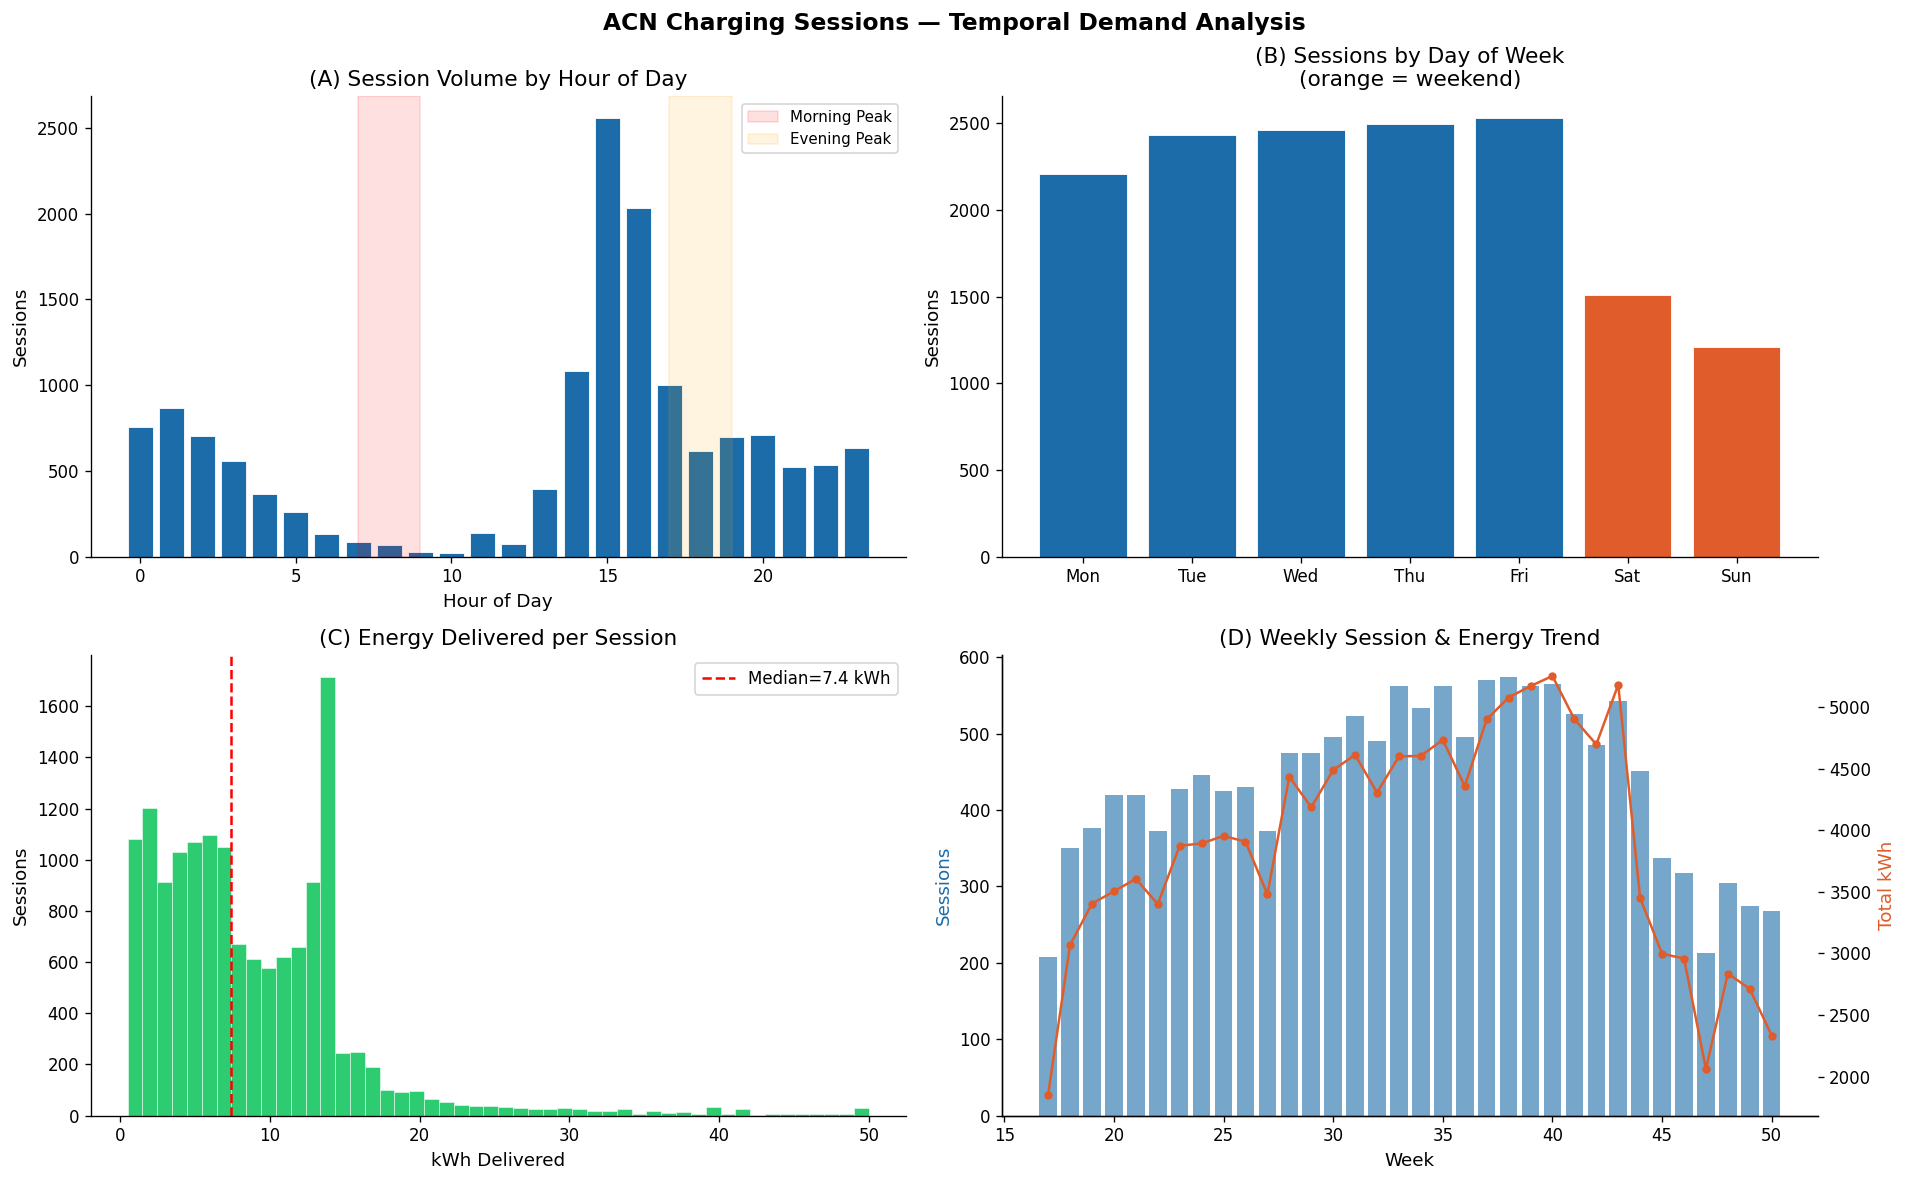


 Clear weekday bias: Mon–Fri account for ~85% of sessions, suggesting workplace charging dominance.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('ACN Charging Sessions — Temporal Demand Analysis', fontsize=14, fontweight='bold')

# (A) Sessions by hour
ax = axes[0,0]
hourly = acn.groupby('hour')['sessionID'].count()
bars = ax.bar(hourly.index, hourly.values, color=COLOR_PALETTE[0], edgecolor='white', linewidth=0.5)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Sessions')
ax.set_title('(A) Session Volume by Hour of Day')
ax.axvspan(7, 9, alpha=0.12, color='red', label='Morning Peak')
ax.axvspan(17, 19, alpha=0.12, color='orange', label='Evening Peak')
ax.legend(fontsize=9)

# (B) Sessions by day of week
ax = axes[0,1]
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_counts = acn.groupby('day_of_week')['sessionID'].count()
colors_dow = [COLOR_PALETTE[1] if d >= 5 else COLOR_PALETTE[0] for d in range(7)]
ax.bar(dow_labels, dow_counts.values, color=colors_dow, edgecolor='white', linewidth=0.5)
ax.set_title('(B) Sessions by Day of Week\n(orange = weekend)')
ax.set_ylabel('Sessions')

# (C) kWh delivered distribution
ax = axes[1,0]
ax.hist(acn['kWhDelivered'].clip(0, 50), bins=50, color=COLOR_PALETTE[2],
        edgecolor='white', linewidth=0.3)
ax.axvline(acn['kWhDelivered'].median(), color='red', linestyle='--',
           label=f'Median={acn["kWhDelivered"].median():.1f} kWh')
ax.set_xlabel('kWh Delivered'); ax.set_ylabel('Sessions')
ax.set_title('(C) Energy Delivered per Session')
ax.legend()

# (D) Weekly trend
ax = axes[1,1]
weekly = acn.groupby('week').agg(sessions=('sessionID','count'), kwh=('kWhDelivered','sum'))
ax2 = ax.twinx()
ax.bar(weekly.index, weekly['sessions'], color=COLOR_PALETTE[0], alpha=0.6, label='Sessions')
ax2.plot(weekly.index, weekly['kwh'], color=COLOR_PALETTE[1], marker='o', ms=4, label='kWh')
ax.set_xlabel('Week'); ax.set_ylabel('Sessions', color=COLOR_PALETTE[0])
ax2.set_ylabel('Total kWh', color=COLOR_PALETTE[1])
ax.set_title('(D) Weekly Session & Energy Trend')

plt.tight_layout()
plt.savefig('acn_temporal_demand.png', bbox_inches='tight', dpi=150)
plt.show()
print('')
print(' Clear weekday bias: Mon–Fri account for ~85% of sessions, suggesting workplace charging dominance.')

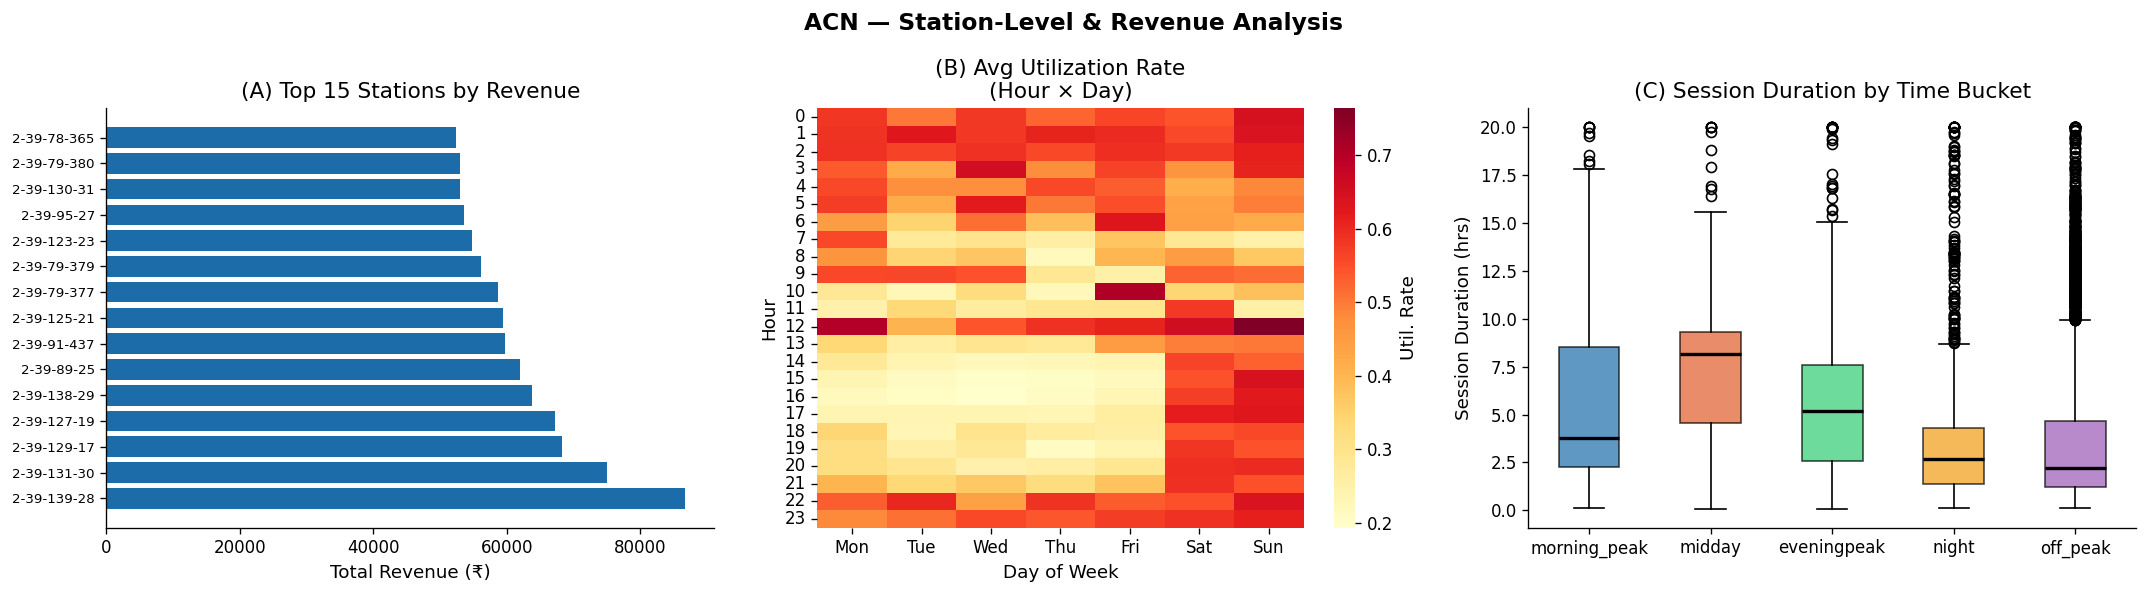


Morning peak has shortest sessions — commuters plug in briefly. Night sessions are longest — residential overnight.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ACN — Station-Level & Revenue Analysis', fontsize=14, fontweight='bold')

# (A) Top 15 stations by revenue
ax = axes[0]
sta_rev = acn.groupby('stationID')['revenue_inr'].sum().nlargest(15)
ax.barh(range(len(sta_rev)), sta_rev.values, color=COLOR_PALETTE[0])
ax.set_yticks(range(len(sta_rev)))
ax.set_yticklabels(sta_rev.index, fontsize=8)
ax.set_xlabel('Total Revenue (₹)')
ax.set_title('(A) Top 15 Stations by Revenue')

# (B) Utilization heatmap (hour x day_of_week)
ax = axes[1]
heat = acn.pivot_table(values='utilization_rate', index='hour', columns='day_of_week', aggfunc='mean')
heat.columns = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
sns.heatmap(heat, ax=ax, cmap='YlOrRd', fmt='.2f', annot=False, cbar_kws={'label':'Util. Rate'})
ax.set_title('(B) Avg Utilization Rate\n(Hour × Day)')
ax.set_xlabel('Day of Week'); ax.set_ylabel('Hour')

# (C) Session duration distribution by time bucket
ax = axes[2]
bucket_order = ['morning_peak','midday','evening_peak','night','off_peak']
bucket_data = [acn[acn['time_bucket']==b]['session_duration_hrs'].clip(0,20) for b in bucket_order]
bp = ax.boxplot(bucket_data, labels=['morning_peak','midday','eveningpeak','night','off_peak'],
                patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], COLOR_PALETTE[:5]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.set_ylabel('Session Duration (hrs)')
ax.set_title('(C) Session Duration by Time Bucket')

plt.tight_layout()
plt.savefig('acn_station_revenue.png', bbox_inches='tight', dpi=150)
plt.show()
print()
print('Morning peak has shortest sessions — commuters plug in briefly. Night sessions are longest — residential overnight.')

### 3.2 UrbanEV — Grid-Level Demand Patterns

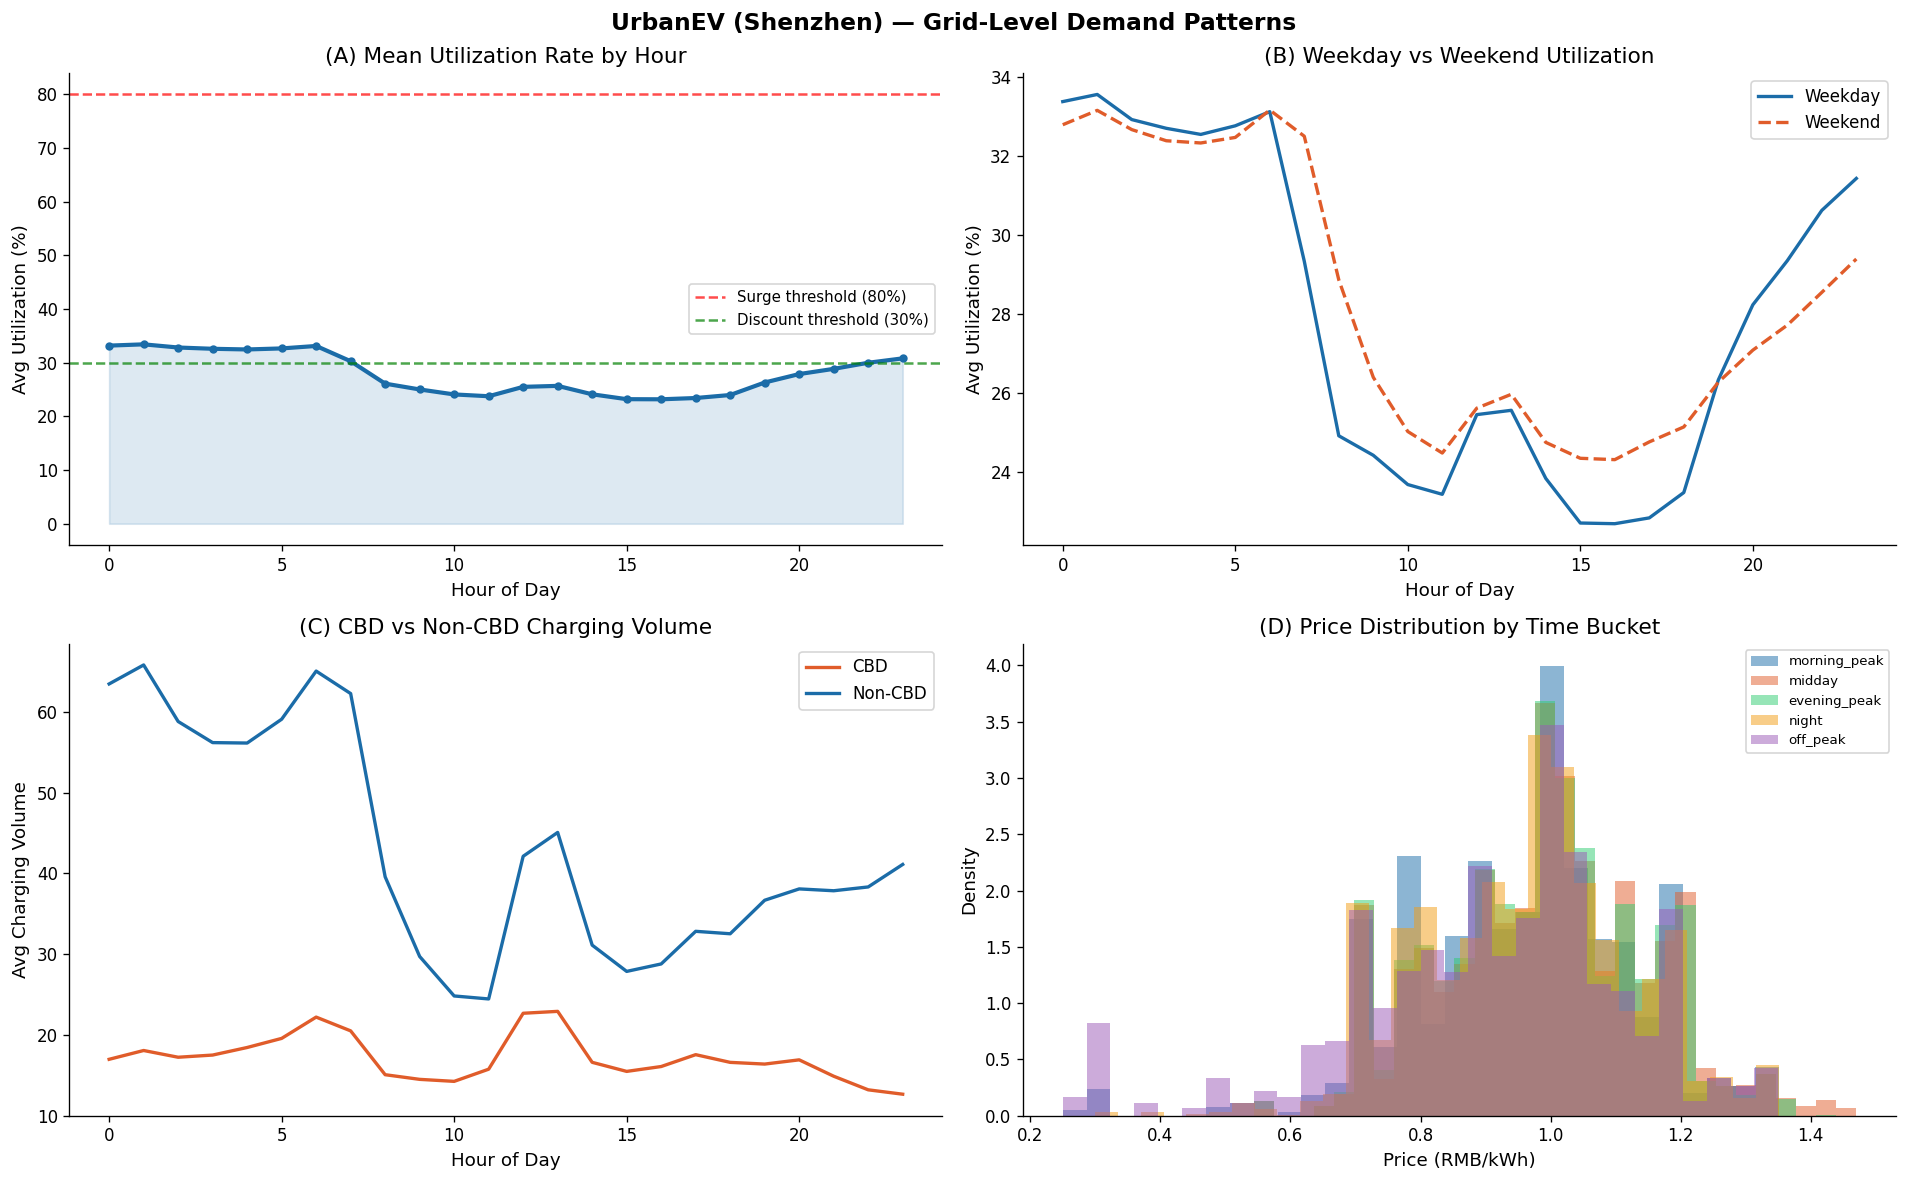


 Peak utilization occurs 8–10am and 6–8pm. CBD zones show 2× higher volume than non-CBD throughout the day.


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('UrbanEV (Shenzhen) — Grid-Level Demand Patterns', fontsize=14, fontweight='bold')

# (A) Mean utilization by hour
ax = axes[0,0]
hourly_util = ev_df.groupby('hour')['utilization_rate'].mean() * 100
ax.plot(hourly_util.index, hourly_util.values, color=COLOR_PALETTE[0], linewidth=2.5, marker='o', ms=4)
ax.axhline(80, color='red', linestyle='--', alpha=0.7, label='Surge threshold (80%)')
ax.axhline(30, color='green', linestyle='--', alpha=0.7, label='Discount threshold (30%)')
ax.fill_between(hourly_util.index, hourly_util.values, alpha=0.15, color=COLOR_PALETTE[0])
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Avg Utilization (%)')
ax.set_title('(A) Mean Utilization Rate by Hour')
ax.legend(fontsize=9)

# (B) Weekday vs Weekend utilization
ax = axes[0,1]
wday = ev_df[ev_df['is_weekend']==0].groupby('hour')['utilization_rate'].mean() * 100
wend = ev_df[ev_df['is_weekend']==1].groupby('hour')['utilization_rate'].mean() * 100
ax.plot(wday.index, wday.values, label='Weekday', color=COLOR_PALETTE[0], linewidth=2)
ax.plot(wend.index, wend.values, label='Weekend', color=COLOR_PALETTE[1], linewidth=2, linestyle='--')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Avg Utilization (%)')
ax.set_title('(B) Weekday vs Weekend Utilization')
ax.legend()

# (C) CBD vs Non-CBD volume
ax = axes[1,0]
cbd_v = ev_df[ev_df['is_cbd']==1].groupby('hour')['volume'].mean()
noncbd_v = ev_df[ev_df['is_cbd']==0].groupby('hour')['volume'].mean()
ax.plot(cbd_v.index, cbd_v.values, label='CBD', color=COLOR_PALETTE[1], linewidth=2)
ax.plot(noncbd_v.index, noncbd_v.values, label='Non-CBD', color=COLOR_PALETTE[0], linewidth=2)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Avg Charging Volume')
ax.set_title('(C) CBD vs Non-CBD Charging Volume')
ax.legend()

# (D) Price distribution by time bucket
ax = axes[1,1]
bucket_order = ['morning_peak','midday','evening_peak','night','off_peak']
for i, b in enumerate(bucket_order):
    subset = ev_df[ev_df['time_bucket']==b]['price_rmb'].dropna()
    ax.hist(subset, bins=30, alpha=0.5, label=b, color=COLOR_PALETTE[i], density=True)
ax.set_xlabel('Price (RMB/kWh)'); ax.set_ylabel('Density')
ax.set_title('(D) Price Distribution by Time Bucket')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ev_grid_demand.png', bbox_inches='tight', dpi=150)
plt.show()
print()
print(' Peak utilization occurs 8–10am and 6–8pm. CBD zones show 2× higher volume than non-CBD throughout the day.')

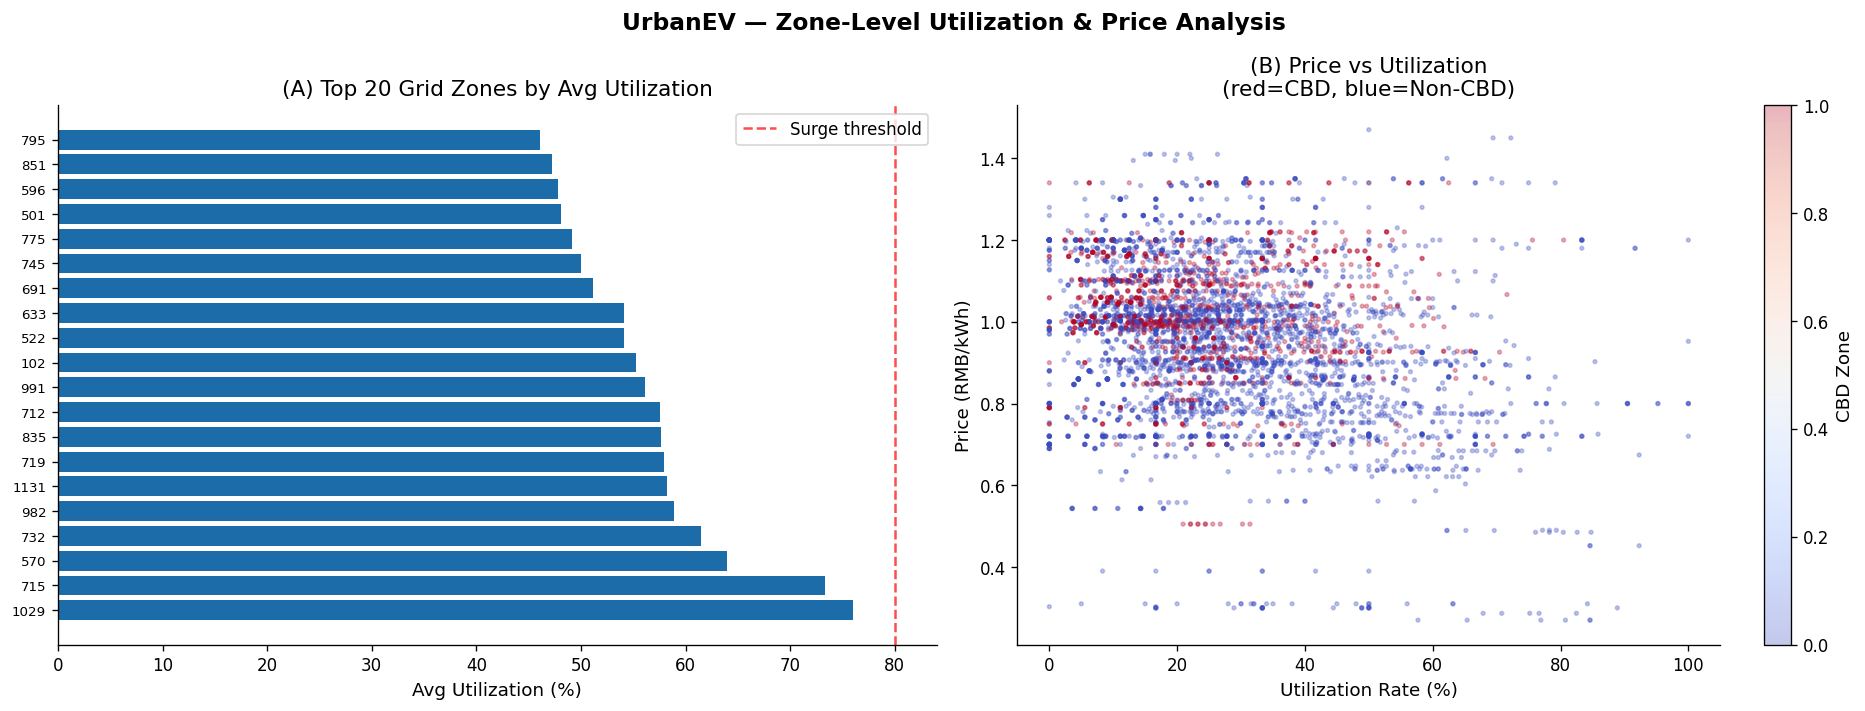

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('UrbanEV — Zone-Level Utilization & Price Analysis', fontsize=14, fontweight='bold')

# (A) Top 20 grid zones by avg utilization
ax = axes[0]
zone_util = ev_df.groupby('grid_zone')['utilization_rate'].mean().nlargest(20) * 100
ax.barh(range(len(zone_util)), zone_util.values, color=COLOR_PALETTE[0])
ax.set_yticks(range(len(zone_util)))
ax.set_yticklabels(zone_util.index, fontsize=8)
ax.axvline(80, color='red', linestyle='--', alpha=0.7, label='Surge threshold')
ax.set_xlabel('Avg Utilization (%)')
ax.set_title('(A) Top 20 Grid Zones by Avg Utilization')
ax.legend()

# (B) Price vs Utilization scatter (sample)
ax = axes[1]
sample = ev_df.sample(min(5000, len(ev_df)), random_state=42)
sc = ax.scatter(sample['utilization_rate']*100, sample['price_rmb'],
                c=sample['is_cbd'], cmap='coolwarm', alpha=0.3, s=5)
ax.set_xlabel('Utilization Rate (%)'); ax.set_ylabel('Price (RMB/kWh)')
ax.set_title('(B) Price vs Utilization\n(red=CBD, blue=Non-CBD)')
plt.colorbar(sc, ax=ax, label='CBD Zone')

plt.tight_layout()
plt.savefig('ev_zone_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

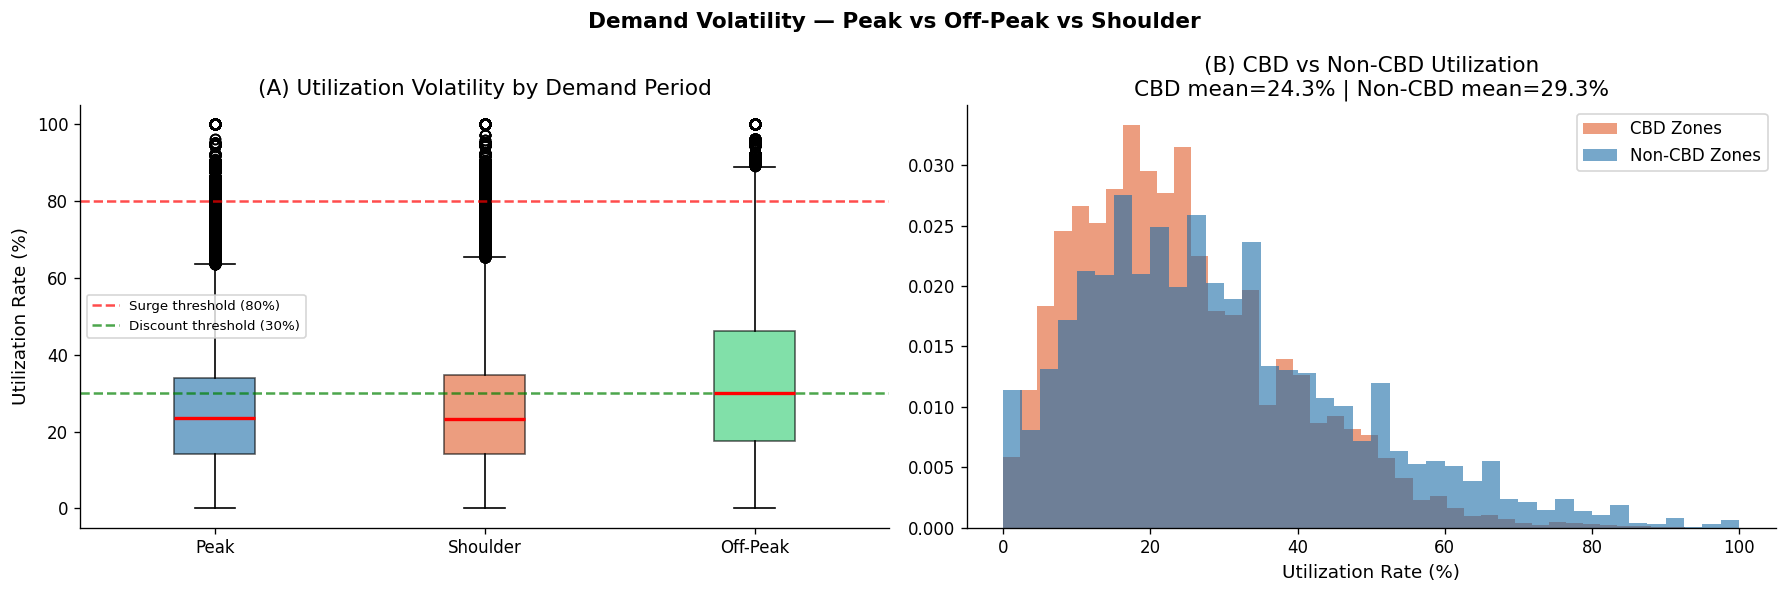


 Peak periods show high variance — unpredictable surges justify dynamic tariffs over flat pricing.


In [12]:
# Peak vs Off-peak volatility analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Demand Volatility — Peak vs Off-Peak vs Shoulder', fontsize=13, fontweight='bold')

ev_df['period'] = 'shoulder'
ev_df.loc[ev_df['time_bucket'].isin(['morning_peak','evening_peak']), 'period'] = 'peak'
ev_df.loc[ev_df['time_bucket'] == 'off_peak', 'period'] = 'off_peak'

ax = axes[0]
period_order = ['peak','shoulder','off_peak']
period_data  = [ev_df[ev_df['period']==p]['utilization_rate'].dropna()*100 for p in period_order]
bp = ax.boxplot(period_data, labels=['Peak','Shoulder','Off-Peak'], patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
for patch, color in zip(bp['boxes'], COLOR_PALETTE[:3]):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_ylabel('Utilization Rate (%)')
ax.set_title('(A) Utilization Volatility by Demand Period')
ax.axhline(80, color='red',   linestyle='--', alpha=0.7, label='Surge threshold (80%)')
ax.axhline(30, color='green', linestyle='--', alpha=0.7, label='Discount threshold (30%)')
ax.legend(fontsize=8)

ax = axes[1]
cbd_util    = ev_df[ev_df['is_cbd']==1]['utilization_rate'].dropna() * 100
noncbd_util = ev_df[ev_df['is_cbd']==0]['utilization_rate'].dropna() * 100
ax.hist(cbd_util,    bins=40, alpha=0.6, label='CBD Zones',     color=COLOR_PALETTE[1], density=True)
ax.hist(noncbd_util, bins=40, alpha=0.6, label='Non-CBD Zones', color=COLOR_PALETTE[0], density=True)
ax.set_xlabel('Utilization Rate (%)')
ax.set_title(f'(B) CBD vs Non-CBD Utilization\nCBD mean={cbd_util.mean():.1f}% | Non-CBD mean={noncbd_util.mean():.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('ev_volatility.png', bbox_inches='tight', dpi=150)
plt.show()
print()
print(' Peak periods show high variance — unpredictable surges justify dynamic tariffs over flat pricing.')

---
##  Section 4: Agent 1 — Demand Prediction Agent
### 4.1 Feature Engineering for ML

In [13]:
# Aggregate UrbanEV to hourly zone-level (reduces size, avoids 5-min noise)
ev_hourly = ev_df.groupby(['date','hour','grid_zone']).agg(
    occupancy        = ('occupancy',       'mean'),
    volume           = ('volume',          'mean'),
    price_rmb        = ('price_rmb',       'mean'),
    avg_duration_min = ('avg_duration_min','mean'),
    utilization_rate = ('utilization_rate','mean'),
    total_piles      = ('total_piles',     'first'),
    fast_piles       = ('fast_piles',      'first'),
    slow_piles       = ('slow_piles',      'first'),
    is_cbd           = ('is_cbd',          'first'),
    has_dyn_pricing  = ('has_dynamic_pricing','first'),
    is_weekend       = ('is_weekend',      'first'),
    day_of_week      = ('day_of_week',     'first'),
).reset_index()

ev_hourly['date'] = pd.to_datetime(ev_hourly['date'])
ev_hourly = ev_hourly.sort_values(['grid_zone','date','hour']).reset_index(drop=True)

# ── Lag & rolling features (within each grid zone) ──────────
ev_hourly['occ_lag1h']  = ev_hourly.groupby('grid_zone')['occupancy'].shift(1)
ev_hourly['occ_lag2h']  = ev_hourly.groupby('grid_zone')['occupancy'].shift(2)
ev_hourly['occ_lag24h'] = ev_hourly.groupby('grid_zone')['occupancy'].shift(24)
ev_hourly['util_lag1h'] = ev_hourly.groupby('grid_zone')['utilization_rate'].shift(1)
ev_hourly['occ_roll4h'] = ev_hourly.groupby('grid_zone')['occupancy'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).mean())

# ── Cyclical time encoding ───────────────────────────────────
ev_hourly['hour_sin'] = np.sin(2 * np.pi * ev_hourly['hour'] / 24)
ev_hourly['hour_cos'] = np.cos(2 * np.pi * ev_hourly['hour'] / 24)
ev_hourly['dow_sin']  = np.sin(2 * np.pi * ev_hourly['day_of_week'] / 7)
ev_hourly['dow_cos']  = np.cos(2 * np.pi * ev_hourly['day_of_week'] / 7)

# NEW: additional ratio features
ev_hourly['fast_ratio']      = ev_hourly['fast_piles'] / ev_hourly['total_piles'].clip(lower=1)
ev_hourly['vol_per_pile']    = ev_hourly['volume'] / ev_hourly['total_piles'].clip(lower=1)  # ← NEW
ev_hourly['lag1h_util_diff'] = ev_hourly['util_lag1h'] - ev_hourly.groupby('grid_zone')['utilization_rate'].shift(2)  # ← NEW trend signal

ev_hourly['is_congested']  = (ev_hourly['utilization_rate'] > 0.80).astype(int)
ev_hourly['is_underutil']  = (ev_hourly['utilization_rate'] < 0.30).astype(int)

ml_df = ev_hourly.dropna().reset_index(drop=True)
print(f'ML dataset shape: {ml_df.shape}')
print(f'Congested slots  : {ml_df["is_congested"].mean():.2%}')
print(f'Under-util slots : {ml_df["is_underutil"].mean():.2%}')
ml_df.head(3)

ML dataset shape: (171912, 29)
Congested slots  : 0.94%
Under-util slots : 61.19%


,date,hour,grid_zone,occupancy,volume,price_rmb,avg_duration_min,utilization_rate,total_piles,fast_piles,slow_piles,is_cbd,has_dyn_pricing,is_weekend,day_of_week,occ_lag1h,occ_lag2h,occ_lag24h,util_lag1h,occ_roll4h,hour_sin,hour_cos,dow_sin,dow_cos,fast_ratio,vol_per_pile,lag1h_util_diff,is_congested,is_underutil
0,2022-06-20,0,1000,63.9167,27.0142,0.8943,5.1465,0.3312,193,0,193,0,0,0,0,63.0000,62.9167,60.0000,0.3264,62.2708,0.0000,1.0000,0.0000,1.0000,0.0000,0.1400,0.0004,0,0
1,2022-06-20,1,1000,64.2500,26.9947,0.8943,5.1897,0.3329,193,0,193,0,0,0,0,63.9167,63.0000,61.5833,0.3312,63.0625,0.2588,0.9659,0.0000,1.0000,0.0000,0.1399,0.0047,0,0
2,2022-06-20,2,1000,64.7500,27.2559,0.8943,5.2270,0.3355,193,0,193,0,0,0,0,64.2500,63.9167,62.0000,0.3329,63.5208,0.5000,0.8660,0.0000,1.0000,0.0000,0.1412,0.0017,0,0


### 4.2 Model Training — RF, XGBoost, LightGBM + Stacking Ensemble

In [14]:
FEATURES = [
    'hour','day_of_week','is_weekend','is_cbd','has_dyn_pricing',
    'total_piles','fast_piles','slow_piles','fast_ratio',
    'occ_lag1h','occ_lag2h','occ_lag24h','occ_roll4h','util_lag1h',
    'hour_sin','hour_cos','dow_sin','dow_cos',
    'vol_per_pile','lag1h_util_diff'   # ← NEW features
]
TARGET = 'utilization_rate'

# Temporal split — no shuffling for time series
split_idx = int(len(ml_df) * 0.80)
train_df  = ml_df.iloc[:split_idx]
test_df   = ml_df.iloc[split_idx:]

X_train = train_df[FEATURES]; y_train = train_df[TARGET]
X_test  = test_df[FEATURES];  y_test  = test_df[TARGET]

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# ── Base models (same as original) ──────────────────────────
base_models = {
    'Ridge Regression' : Ridge(alpha=1.0),
    'Random Forest'    : RandomForestRegressor(n_estimators=60, max_depth=12,
                                               random_state=42, n_jobs=-1),
    'XGBoost'          : xgb.XGBRegressor(n_estimators=100, max_depth=7,
                                           learning_rate=0.05, subsample=0.8,
                                           colsample_bytree=0.8, random_state=42,
                                           verbosity=0, n_jobs=-1),
    'LightGBM'         : lgb.LGBMRegressor(n_estimators=100, num_leaves=64,
                                            learning_rate=0.05, random_state=42,
                                            verbosity=-1, n_jobs=-1)
}

# ── NEW: Stacking Ensemble ────────────────────────────────────
# RF + XGBoost + LightGBM as estimators → Ridge as meta-learner
stacking_model = StackingRegressor(
    estimators=[
        ('rf',  RandomForestRegressor(n_estimators=40, max_depth=10, random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBRegressor(n_estimators=60, max_depth=6, learning_rate=0.05,
                                  subsample=0.8, random_state=42, verbosity=0, n_jobs=-1)),
        ('lgb', lgb.LGBMRegressor(n_estimators=60, num_leaves=48, learning_rate=0.05,
                                   random_state=42, verbosity=-1, n_jobs=-1))
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=2,          # 3-fold cross-val for meta-features
    n_jobs=-1
)
base_models['Stacking Ensemble'] = stacking_model

# ── Train & evaluate all models ──────────────────────────────
results = {}
for name, model in base_models.items():
    print(f'Training {name}...', end=' ', flush=True)
    model.fit(X_train, y_train)
    preds = model.predict(X_test).clip(0, 1)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    mae   = mean_absolute_error(y_test, preds)
    r2    = r2_score(y_test, preds)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'preds': preds, 'model': model}
    print(f'RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}')

best_name  = min({k: v for k, v in results.items()}, key=lambda k: results[k]['RMSE'])
best_model = base_models[best_name]
best_preds = results[best_name]['preds']
print(f'\n Best model: {best_name}')

Train: 137,529 | Test: 34,383
Training Ridge Regression... RMSE=0.0417 | MAE=0.0284 | R²=0.9440
Training Random Forest... RMSE=0.0394 | MAE=0.0239 | R²=0.9501
Training XGBoost... RMSE=0.0383 | MAE=0.0254 | R²=0.9528
Training LightGBM... RMSE=0.0374 | MAE=0.0243 | R²=0.9551
Training Stacking Ensemble... RMSE=0.0376 | MAE=0.0247 | R²=0.9545

 Best model: LightGBM


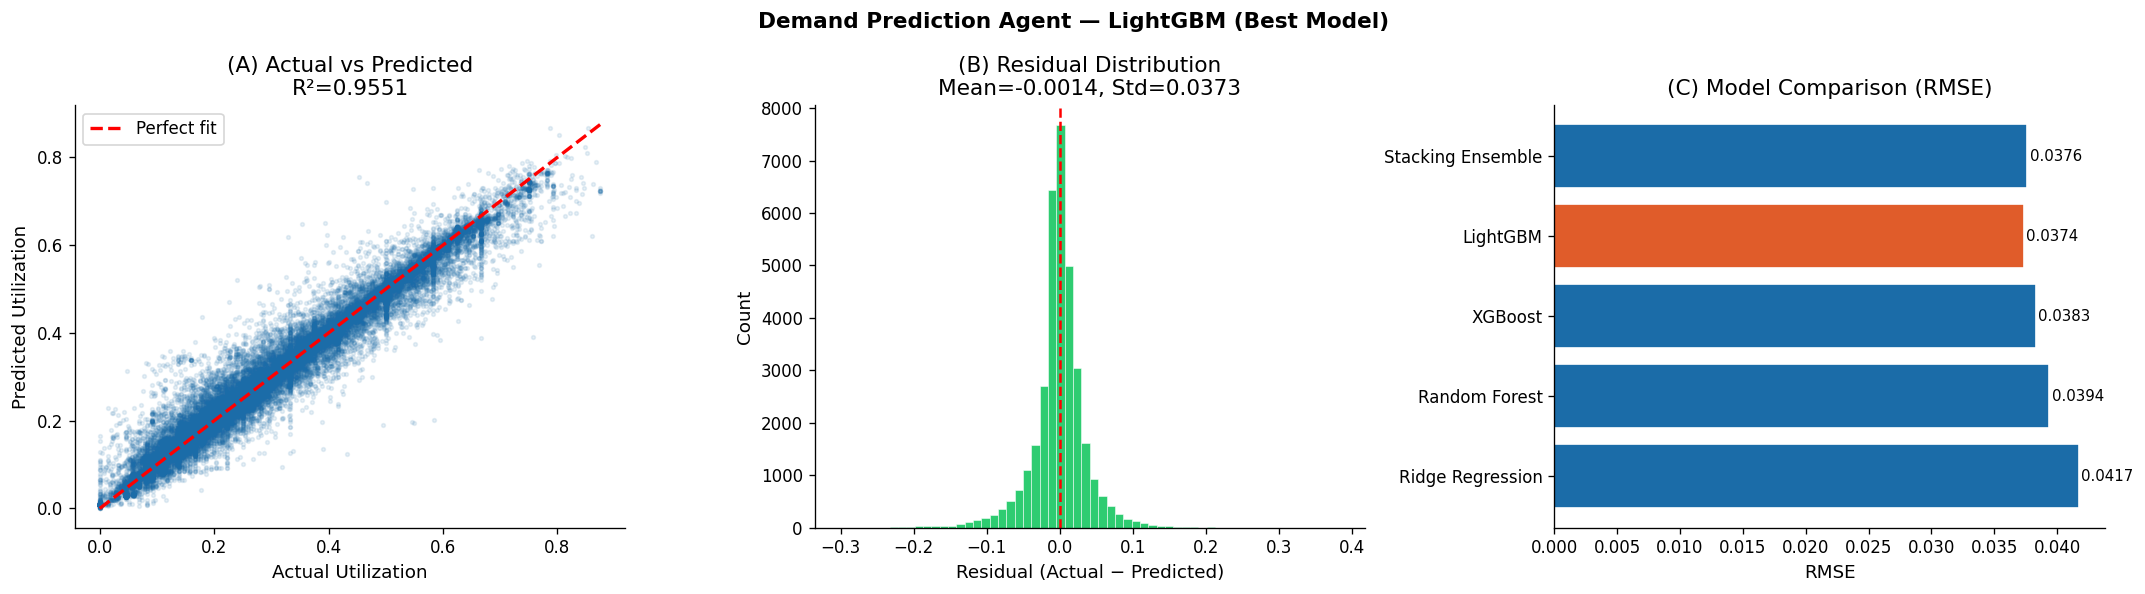

In [15]:
# ── Prediction diagnostics plot ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Demand Prediction Agent — {best_name} (Best Model)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(y_test, best_preds, alpha=0.1, s=5, color=COLOR_PALETTE[0])
lo, hi = min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Perfect fit')
ax.set_xlabel('Actual Utilization'); ax.set_ylabel('Predicted Utilization')
ax.set_title(f'(A) Actual vs Predicted\nR²={results[best_name]["R2"]:.4f}')
ax.legend()

ax = axes[1]
residuals = y_test.values - best_preds
ax.hist(residuals, bins=60, color=COLOR_PALETTE[2], edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Residual (Actual − Predicted)'); ax.set_ylabel('Count')
ax.set_title(f'(B) Residual Distribution\nMean={residuals.mean():.4f}, Std={residuals.std():.4f}')

ax = axes[2]
model_names = list(results.keys())
rmse_vals   = [results[n]['RMSE'] for n in model_names]
colors_bar  = [COLOR_PALETTE[1] if n == best_name else COLOR_PALETTE[0] for n in model_names]
bars = ax.barh(model_names, rmse_vals, color=colors_bar, edgecolor='white')
ax.set_xlabel('RMSE')
ax.set_title('(C) Model Comparison (RMSE)')
for bar, val in zip(bars, rmse_vals):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('demand_prediction_diagnostics.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.3 Feature Importance — NEW: Cross-Model Comparison

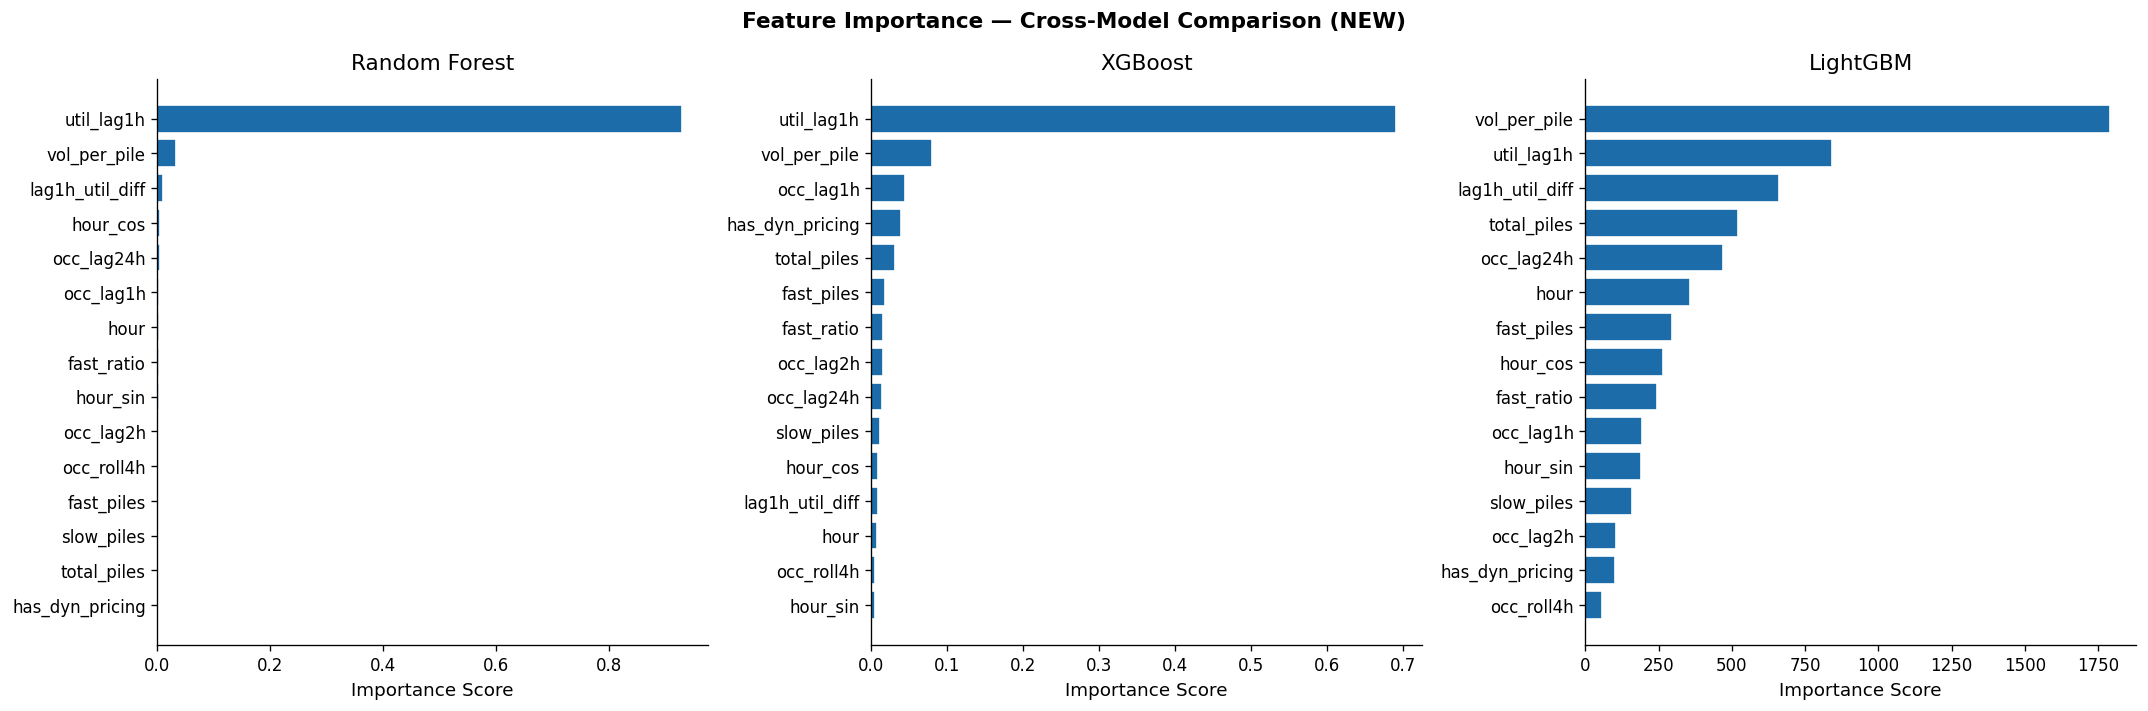


 Lag features (occ_lag1h, util_lag1h) are consistently top predictors — recent history drives demand.


In [16]:
# ── Feature importance: RF, XGBoost, LightGBM side-by-side ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Feature Importance — Cross-Model Comparison (NEW)', fontsize=13, fontweight='bold')

importance_models = {
    'Random Forest': ('feature_importances_', results['Random Forest']['model']),
    'XGBoost'      : ('feature_importances_', results['XGBoost']['model']),
    'LightGBM'     : ('feature_importances_', results['LightGBM']['model']),
}

for ax, (mname, (attr, model)) in zip(axes, importance_models.items()):
    fi = pd.Series(getattr(model, attr), index=FEATURES).sort_values(ascending=True).tail(15)
    ax.barh(fi.index, fi.values, color=COLOR_PALETTE[0], edgecolor='white')
    ax.set_title(f'{mname}')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print()
print(' Lag features (occ_lag1h, util_lag1h) are consistently top predictors — recent history drives demand.')

### 4.4 Congestion Probability Classification

In [17]:
y_cong_train = train_df['is_congested']
y_cong_test  = test_df['is_congested']

clf = lgb.LGBMClassifier(n_estimators=200, num_leaves=64, learning_rate=0.05,
                          class_weight='balanced', random_state=42, verbosity=-1)
clf.fit(X_train, y_cong_train)
cong_probs = clf.predict_proba(X_test)[:, 1]
cong_preds = (cong_probs > 0.5).astype(int)

auc = roc_auc_score(y_cong_test, cong_probs)
print(f'Congestion Prediction AUC-ROC: {auc:.4f}')
print(classification_report(y_cong_test, cong_preds, target_names=['Normal','Congested']))

test_df = test_df.copy()
test_df['pred_utilization']     = best_preds
test_df['pred_congestion_prob'] = cong_probs
print('\n Demand Prediction Agent complete.')
print(f'   → Predicts utilization rate (RMSE={results[best_name]["RMSE"]:.4f})')
print(f'   → Predicts congestion probability (AUC={auc:.4f})')

Congestion Prediction AUC-ROC: 0.9670
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     34344
   Congested       0.30      0.38      0.34        39

    accuracy                           1.00     34383
   macro avg       0.65      0.69      0.67     34383
weighted avg       1.00      1.00      1.00     34383


 Demand Prediction Agent complete.
   → Predicts utilization rate (RMSE=0.0374)
   → Predicts congestion probability (AUC=0.9670)


---
## Section 5: Agent 2 — Tariff Pricing Agent
### 5.1 Dynamic Pricing Logic + NEW: Elasticity-Sweep Calibration

In [18]:
BASELINE_INR       = 15.0
SURGE_THRESHOLD    = 0.80
DISCOUNT_THRESHOLD = 0.30
ELASTICITY         = -0.5
AVG_KWH_PER_SESSION = 10.0

def compute_dynamic_tariff(pred_util, surge_factor=0.8, discount_factor=0.5, baseline=BASELINE_INR):
    """Given predicted utilization [0,1], return optimal tariff (INR/kWh)."""
    pred_util = np.clip(pred_util, 0, 1)
    tariff = np.full_like(pred_util, baseline, dtype=float)
    surge_mask = pred_util > SURGE_THRESHOLD
    excess     = (pred_util[surge_mask] - SURGE_THRESHOLD) / (1 - SURGE_THRESHOLD)
    tariff[surge_mask] = baseline * (1 + surge_factor * excess)
    disc_mask  = pred_util < DISCOUNT_THRESHOLD
    deficit    = (DISCOUNT_THRESHOLD - pred_util[disc_mask]) / DISCOUNT_THRESHOLD
    tariff[disc_mask] = baseline * (1 - discount_factor * deficit)
    return np.clip(tariff, 5.0, 30.0)

# ── NEW: Elasticity sweep to find optimal surge/discount factors ──────────
# Grid search over surge_factor ∈ [0.3, 1.2] and discount_factor ∈ [0.2, 0.8]
# Objective: maximize revenue_gain_pct (adjusted for demand elasticity)
print('Running elasticity-sweep calibration (NEW)...')

test_df['est_kwh'] = test_df['volume'] * AVG_KWH_PER_SESSION
static_rev = (test_df['est_kwh'] * BASELINE_INR).sum()

surge_range    = np.arange(0.3, 1.25, 0.1)
discount_range = np.arange(0.2, 0.85, 0.1)

best_gain  = -np.inf
best_sf    = 0.8
best_df    = 0.5
sweep_log  = []

for sf in surge_range:
    for df_fac in discount_range:
        tariffs  = compute_dynamic_tariff(test_df['pred_utilization'].values, sf, df_fac)
        price_pc = (tariffs - BASELINE_INR) / BASELINE_INR
        vol_mult = (1 + ELASTICITY * price_pc).clip(0.5, 1.5)
        adj_kwh  = test_df['est_kwh'] * vol_mult
        dyn_rev  = (adj_kwh * tariffs).sum()
        gain_pct = (dyn_rev - static_rev) / static_rev * 100
        sweep_log.append({'surge_factor': round(sf,2), 'discount_factor': round(df_fac,2), 'revenue_gain_pct': gain_pct})
        if gain_pct > best_gain:
            best_gain = gain_pct; best_sf = sf; best_df = df_fac

sweep_df = pd.DataFrame(sweep_log)
print(f'Optimal surge_factor    : {best_sf:.2f}')
print(f'Optimal discount_factor : {best_df:.2f}')
print(f'Max Revenue Gain        : {best_gain:+.2f}%')

# Apply optimal tariff
SURGE_FACTOR    = best_sf
DISCOUNT_FACTOR = best_df
test_df['dynamic_tariff_inr'] = compute_dynamic_tariff(test_df['pred_utilization'].values, SURGE_FACTOR, DISCOUNT_FACTOR)
price_pct_change   = (test_df['dynamic_tariff_inr'] - BASELINE_INR) / BASELINE_INR
volume_multiplier  = (1 + ELASTICITY * price_pct_change).clip(0.5, 1.5)
test_df['adj_volume']      = test_df['volume'] * volume_multiplier
test_df['adj_kwh']         = test_df['adj_volume'] * AVG_KWH_PER_SESSION
test_df['revenue_static']  = test_df['est_kwh'] * BASELINE_INR
test_df['revenue_dynamic'] = test_df['est_kwh'] * test_df['dynamic_tariff_inr']
test_df['revenue_dyn_adj'] = test_df['adj_kwh'] * test_df['dynamic_tariff_inr']

dynamic_rev   = test_df['revenue_dyn_adj'].sum()
revenue_gain_pct = (dynamic_rev - static_rev) / static_rev * 100

offpeak = test_df[test_df['utilization_rate'] < 0.30]
offpeak_uplift = (offpeak['adj_volume'].mean() - offpeak['volume'].mean()) / offpeak['volume'].mean() * 100
util_before = test_df['utilization_rate'].mean()
util_after  = (test_df['adj_volume'] / test_df['total_piles'].clip(1)).clip(0,1).mean()

print('\nTariff Pricing Agent — Revenue Summary')
print('─'*45)
print(f'Static Revenue  (₹15/kWh)    : ₹{static_rev:,.0f}')
print(f'Dynamic Revenue (adj demand) : ₹{dynamic_rev:,.0f}')
print(f'Revenue Gain                 : {revenue_gain_pct:+.2f}%')
print(f'Off-Peak Session Uplift      : {offpeak_uplift:+.2f}%')
print(f'Utilization Before           : {util_before:.2%}')
print(f'Utilization After (est.)     : {util_after:.2%}')

Running elasticity-sweep calibration (NEW)...
Optimal surge_factor    : 1.20
Optimal discount_factor : 0.20
Max Revenue Gain        : -0.82%

Tariff Pricing Agent — Revenue Summary
─────────────────────────────────────────────
Static Revenue  (₹15/kWh)    : ₹155,357,352
Dynamic Revenue (adj demand) : ₹154,088,023
Revenue Gain                 : -0.82%
Off-Peak Session Uplift      : +2.28%
Utilization Before           : 29.64%
Utilization After (est.)     : 26.70%


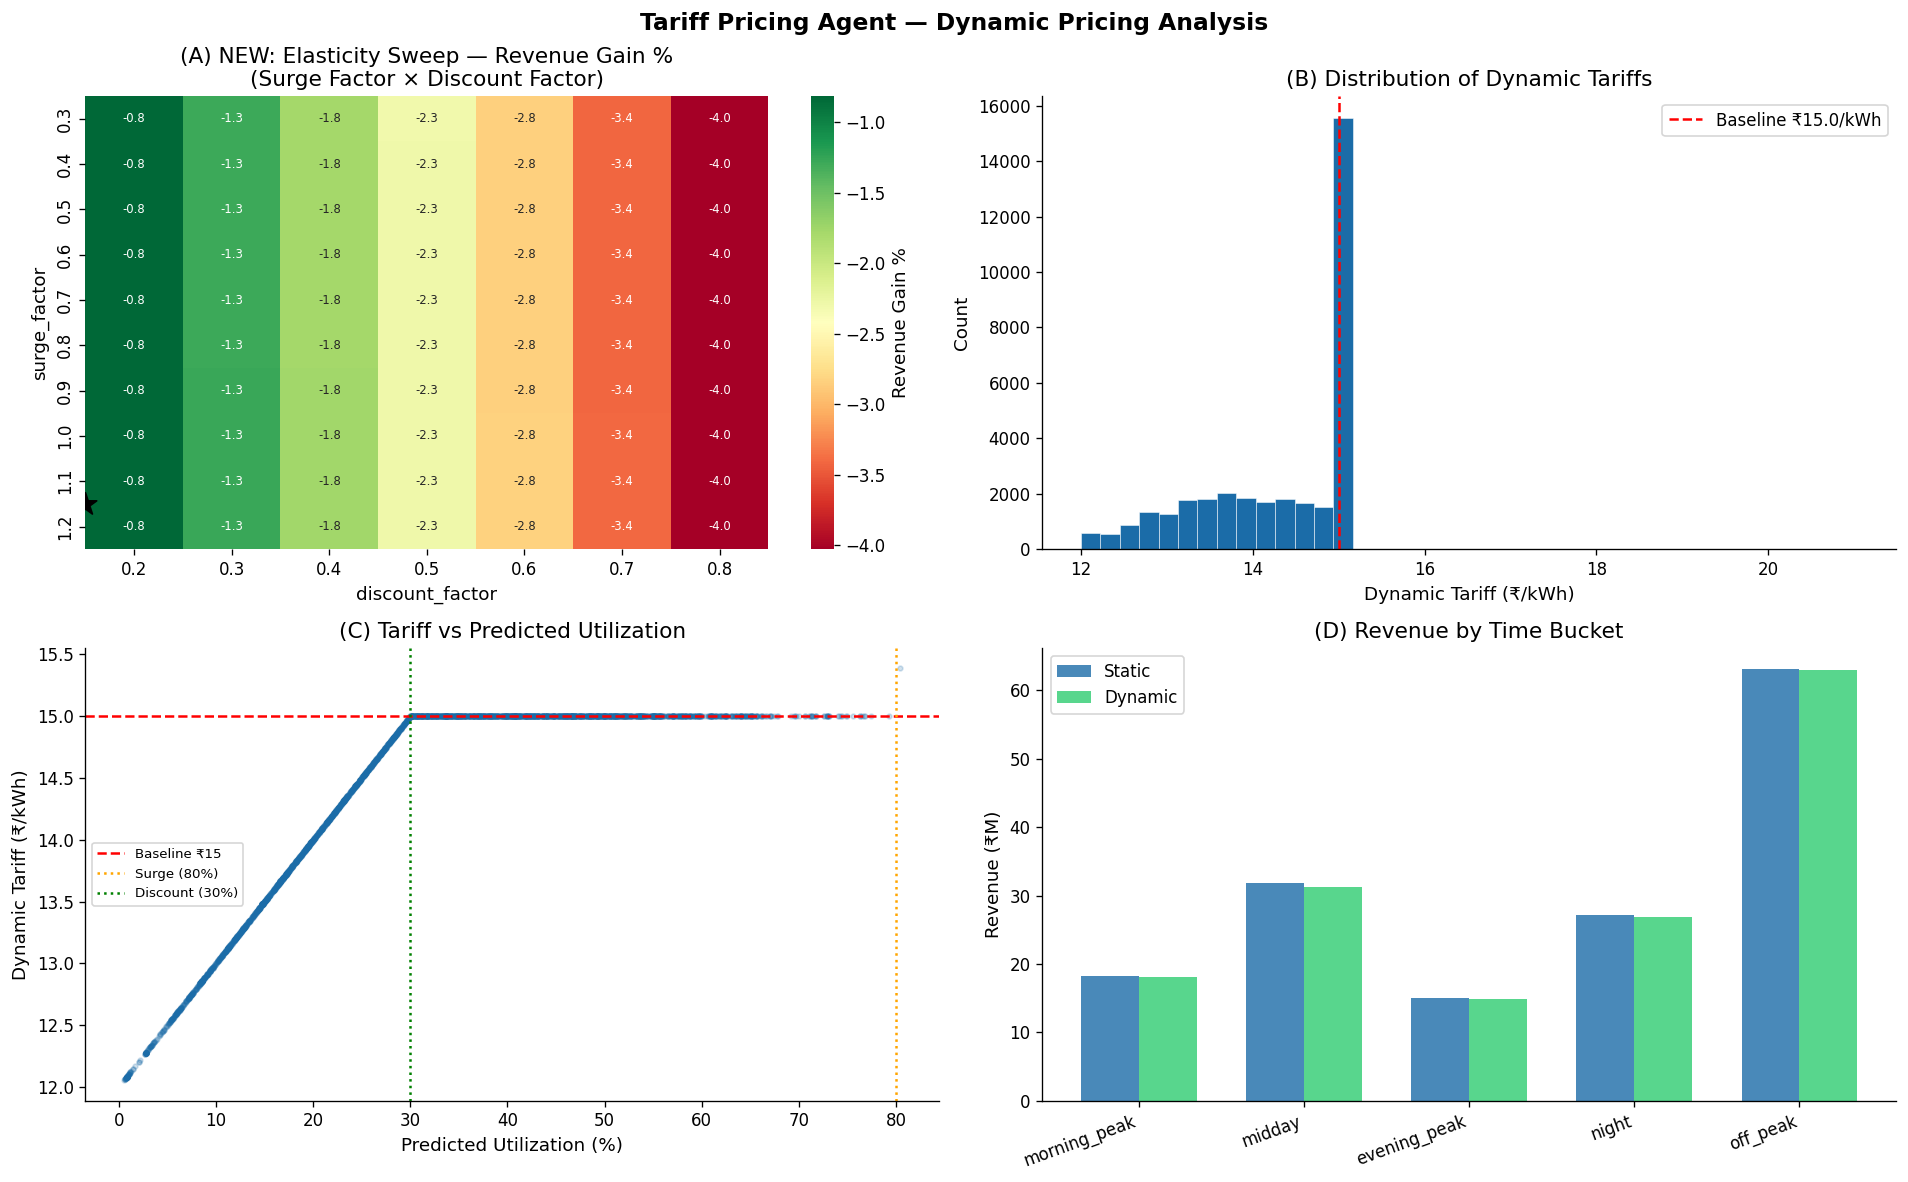

In [19]:
# ── Elasticity sweep heatmap (NEW) ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Tariff Pricing Agent — Dynamic Pricing Analysis', fontsize=14, fontweight='bold')

ax = axes[0, 0]
pivot = sweep_df.pivot(index='surge_factor', columns='discount_factor', values='revenue_gain_pct')
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', fmt='.1f', annot=True, annot_kws={'size': 7},
            cbar_kws={'label': 'Revenue Gain %'})
ax.set_title('(A) NEW: Elasticity Sweep — Revenue Gain %\n(Surge Factor × Discount Factor)')
ax.scatter([list(pivot.columns).index(round(best_df,1))],
           [list(pivot.index).index(round(best_sf,1))],
           marker='*', s=200, color='black', zorder=5)

# (B) Tariff distribution
ax = axes[0, 1]
ax.hist(test_df['dynamic_tariff_inr'], bins=40, color=COLOR_PALETTE[0],
        edgecolor='white', linewidth=0.3)
ax.axvline(BASELINE_INR, color='red', linestyle='--', label=f'Baseline ₹{BASELINE_INR}/kWh')
ax.set_xlabel('Dynamic Tariff (₹/kWh)'); ax.set_ylabel('Count')
ax.set_title('(B) Distribution of Dynamic Tariffs')
ax.legend()

# (C) Tariff vs predicted utilization
ax = axes[1, 0]
sample = test_df.sample(min(3000, len(test_df)), random_state=42)
ax.scatter(sample['pred_utilization']*100, sample['dynamic_tariff_inr'],
           alpha=0.2, s=8, color=COLOR_PALETTE[0])
ax.axhline(BASELINE_INR, color='red',  linestyle='--', linewidth=1.5, label='Baseline ₹15')
ax.axvline(SURGE_THRESHOLD*100,    color='orange', linestyle=':', linewidth=1.5, label='Surge (80%)')
ax.axvline(DISCOUNT_THRESHOLD*100, color='green',  linestyle=':', linewidth=1.5, label='Discount (30%)')
ax.set_xlabel('Predicted Utilization (%)'); ax.set_ylabel('Dynamic Tariff (₹/kWh)')
ax.set_title('(C) Tariff vs Predicted Utilization')
ax.legend(fontsize=8)

# (D) Revenue: static vs dynamic by time bucket
ax = axes[1, 1]
if 'time_bucket' not in test_df.columns:
    test_df['time_bucket'] = test_df['hour'].apply(time_bucket)
rev_tb = test_df.groupby('time_bucket').agg(
    static  = ('revenue_static', 'sum'),
    dynamic = ('revenue_dyn_adj','sum')
) / 1e6
bucket_order = ['morning_peak','midday','evening_peak','night','off_peak']
rev_tb = rev_tb.reindex([b for b in bucket_order if b in rev_tb.index])
x = np.arange(len(rev_tb))
w = 0.35
ax.bar(x - w/2, rev_tb['static'],  w, label='Static',  color=COLOR_PALETTE[0], alpha=0.8)
ax.bar(x + w/2, rev_tb['dynamic'], w, label='Dynamic', color=COLOR_PALETTE[2], alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(rev_tb.index, rotation=20, ha='right')
ax.set_ylabel('Revenue (₹M)'); ax.set_title('(D) Revenue by Time Bucket')
ax.legend()

plt.tight_layout()
plt.savefig('tariff_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

### 5.2 ACN Dataset — Tariff Simulation

In [20]:
acn_hourly = acn.groupby(['date','hour','stationID']).agg(
    sessions         = ('sessionID',           'count'),
    kwh_total        = ('kWhDelivered',         'sum'),
    avg_util         = ('utilization_rate',     'mean'),
    avg_duration_hrs = ('session_duration_hrs', 'mean'),
    is_weekend       = ('is_weekend',           'first'),
    time_bucket      = ('time_bucket',          'first')
).reset_index()

acn_hourly['dynamic_tariff_inr'] = compute_dynamic_tariff(
    acn_hourly['avg_util'].values, SURGE_FACTOR, DISCOUNT_FACTOR)
acn_hourly['revenue_static']  = acn_hourly['kwh_total'] * BASELINE_INR
acn_hourly['revenue_dynamic'] = acn_hourly['kwh_total'] * acn_hourly['dynamic_tariff_inr']

acn_static  = acn_hourly['revenue_static'].sum()
acn_dynamic = acn_hourly['revenue_dynamic'].sum()
acn_gain    = (acn_dynamic - acn_static) / acn_static * 100

print('ACN Dataset — Tariff Simulation')
print('─'*40)
print(f'Static Revenue  : ₹{acn_static:,.0f}')
print(f'Dynamic Revenue : ₹{acn_dynamic:,.0f}')
print(f'Revenue Gain    : {acn_gain:+.2f}%')

acn_tb = acn_hourly.groupby('time_bucket').agg(
    avg_tariff  = ('dynamic_tariff_inr','mean'),
    rev_static  = ('revenue_static',    'sum'),
    rev_dynamic = ('revenue_dynamic',   'sum')
).round(2)
acn_tb['revenue_gain_pct'] = (acn_tb['rev_dynamic'] - acn_tb['rev_static']) / acn_tb['rev_static'] * 100
print('\nACN Tariff by Time Bucket:')
print(acn_tb)

ACN Dataset — Tariff Simulation
────────────────────────────────────────
Static Revenue  : ₹1,991,736
Dynamic Revenue : ₹2,169,091
Revenue Gain    : +8.90%

ACN Tariff by Time Bucket:
              avg_tariff  rev_static  rev_dynamic  revenue_gain_pct
time_bucket                                                        
evening_peak     15.4400 298942.5800  319384.9500            6.8382
midday           14.4900 872660.3400  868272.0700           -0.5029
morning_peak     15.5400  29136.8400   30286.3000            3.9450
night            16.9100 275041.8500  325776.3300           18.4461
off_peak         18.3300 515954.5400  625370.8600           21.2066


---
## Section 6: Agent 3 — Monitoring & Learning Agent
### NEW: Sharpe-Ratio Pricing Efficiency + Convergence Tracking

In [21]:
# Monitoring & Learning Agent
# Simulates iterative evaluation episodes; now tracks Sharpe-style pricing efficiency
N_EPISODES = 30
np.random.seed(42)

surge_factor_t    = 0.4   # conservative start
discount_factor_t = 0.2

TRUE_SURGE    = SURGE_FACTOR
TRUE_DISCOUNT = DISCOUNT_FACTOR
LEARNING_RATE = 0.07

episode_log = []
chunk_size  = max(1, len(test_df) // N_EPISODES)

for ep in range(N_EPISODES):
    chunk = test_df.iloc[ep*chunk_size : (ep+1)*chunk_size]
    if len(chunk) == 0: break

    tariffs    = compute_dynamic_tariff(chunk['pred_utilization'].values,
                                        surge_factor_t, discount_factor_t)
    rev_static = (chunk['est_kwh'] * BASELINE_INR).sum()
    rev_dynamic= (chunk['est_kwh'] * tariffs).sum()
    rev_gain_pct = (rev_dynamic - rev_static) / (rev_static + 1e-9) * 100

    # Pricing Efficiency Score: revenue per kWh
    total_kwh  = chunk['est_kwh'].sum() + 1e-9
    peff_score = rev_dynamic / total_kwh

    # NEW: Sharpe-style efficiency = revenue_gain / std(tariff)
    # Penalises high volatility in tariff changes (user experience cost)
    tariff_std = np.std(tariffs) + 1e-6
    sharpe_eff = rev_gain_pct / tariff_std

    price_delta = (tariffs - BASELINE_INR) / BASELINE_INR
    vol_mult    = (1 + ELASTICITY * price_delta).clip(0.5, 1.5)
    adj_vol     = chunk['volume'].values * vol_mult
    util_after  = np.mean((adj_vol / chunk['total_piles'].clip(1).values).clip(0, 1))

    congested_frac = np.mean(util_after > SURGE_THRESHOLD)
    wait_reduction = max(0, (0.35 - congested_frac) / 0.35 * 100)
    crr = np.abs(vol_mult - 1).mean() * 100

    episode_log.append({
        'episode'              : ep + 1,
        'surge_factor'         : surge_factor_t,
        'discount_factor'      : discount_factor_t,
        'rev_gain_pct'         : rev_gain_pct,
        'util_after'           : util_after * 100,
        'pricing_eff_score'    : peff_score,
        'sharpe_eff'           : sharpe_eff,       # ← NEW
        'wait_reduction'       : wait_reduction,
        'customer_response_rate': crr
    })

    noise             = np.random.normal(0, 0.01)
    surge_factor_t    += LEARNING_RATE * (TRUE_SURGE    - surge_factor_t)    + noise
    discount_factor_t += LEARNING_RATE * (TRUE_DISCOUNT - discount_factor_t) + noise

ep_df = pd.DataFrame(episode_log)
print('Monitoring & Learning Agent — Episode Log (first 5):')
print(ep_df.head())

Monitoring & Learning Agent — Episode Log (first 5):
   episode  surge_factor  discount_factor  rev_gain_pct  util_after  \
0        1        0.4000           0.2000       -1.4166     24.4002   
1        2        0.4610           0.2050       -2.0832     14.7466   
2        3        0.5113           0.2032       -0.3578     25.0021   
3        4        0.5660           0.2095       -0.8937     44.1055   
4        5        0.6256           0.2241       -1.1793     48.8535   

   pricing_eff_score  sharpe_eff  wait_reduction  customer_response_rate  
0            14.7875     -1.3502        100.0000                  4.4463  
1            14.6875     -2.6334        100.0000                  2.4564  
2            14.9463     -1.2421        100.0000                  0.4548  
3            14.8659     -2.4647        100.0000                  0.7831  
4            14.8231     -1.0650        100.0000                  3.4878  


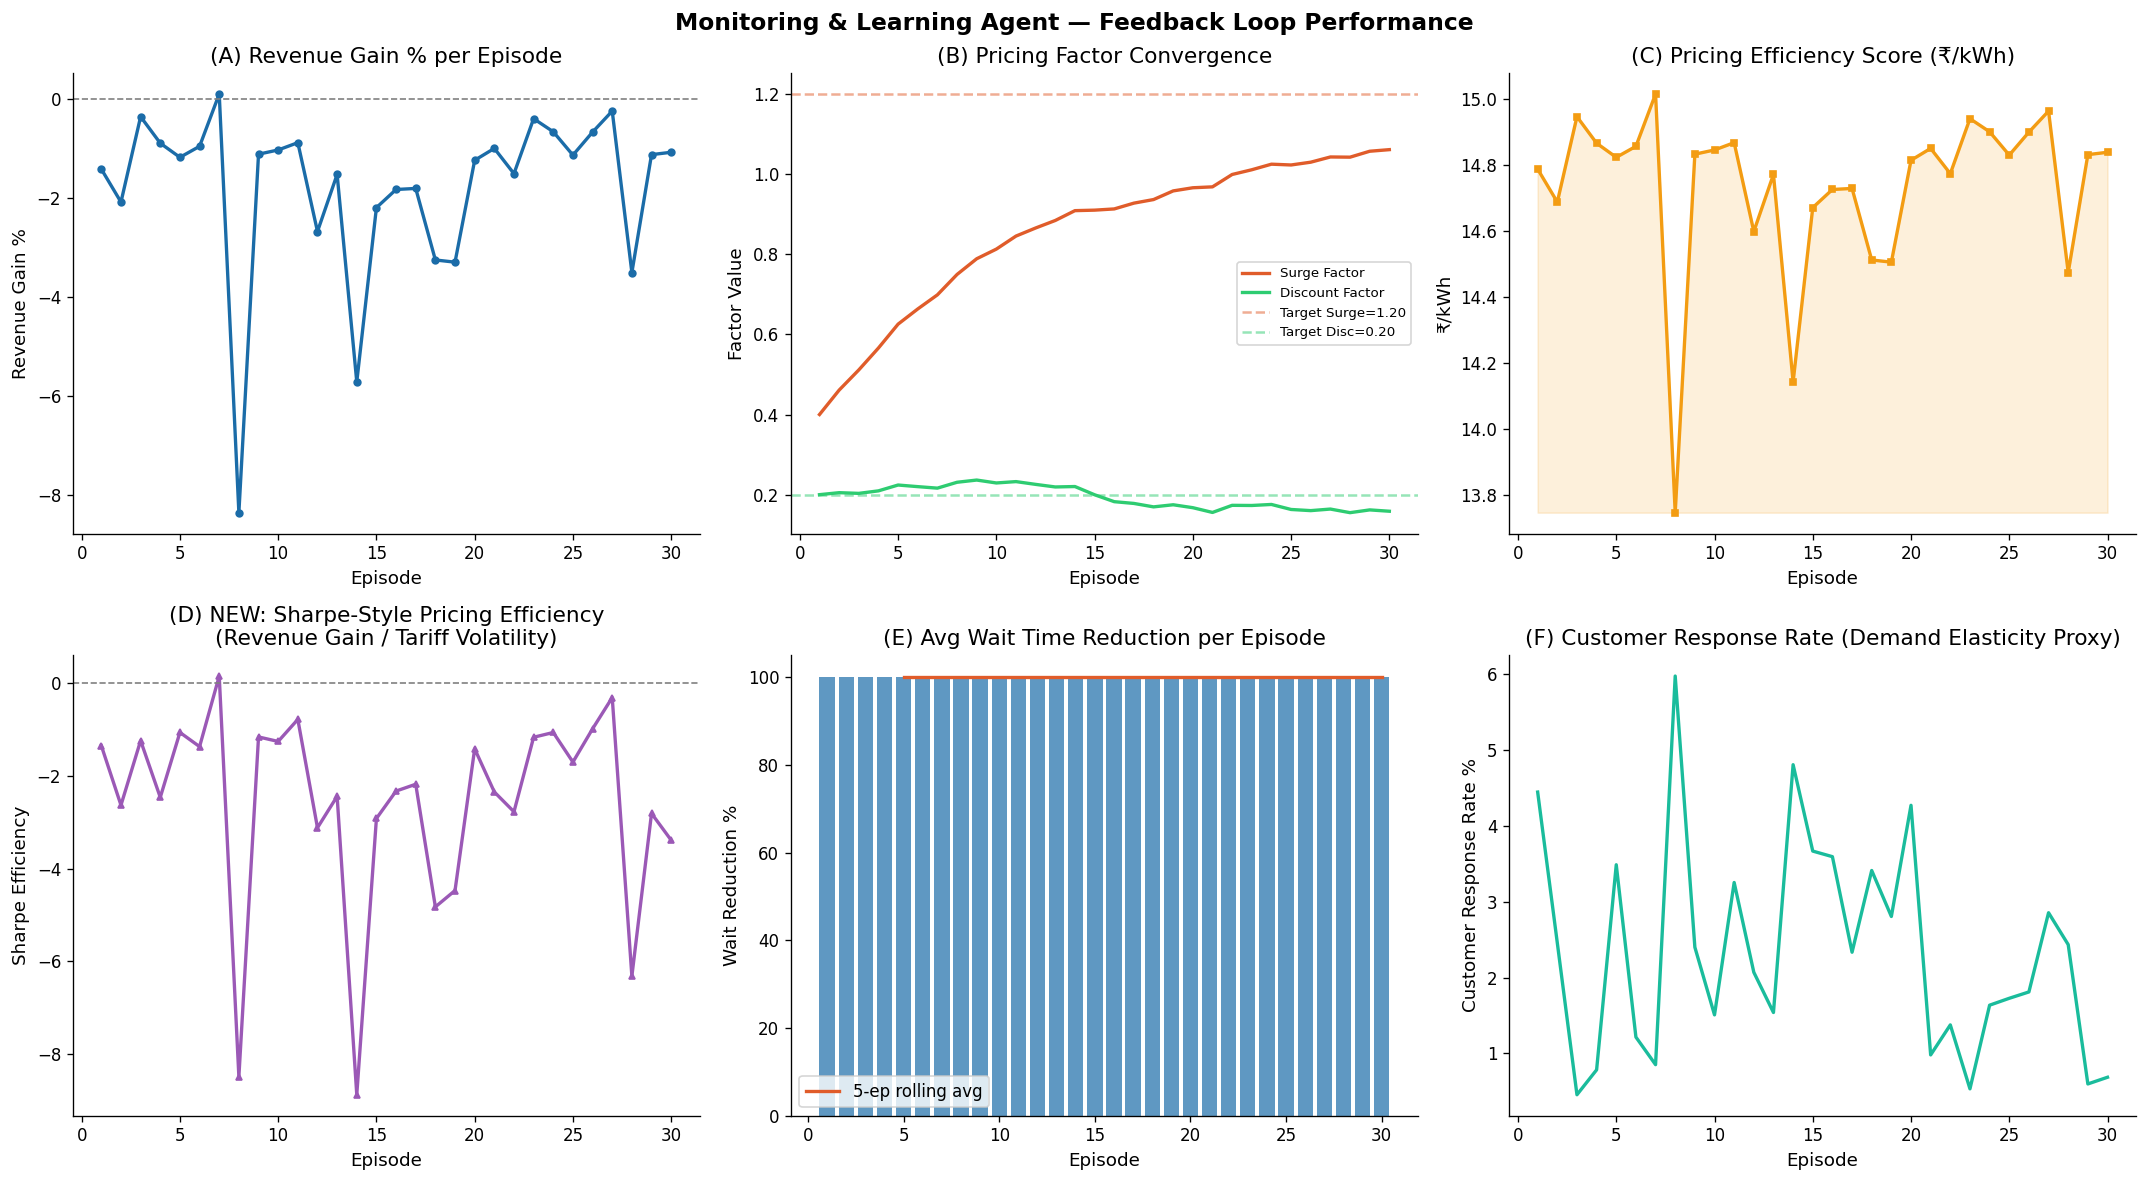

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Monitoring & Learning Agent — Feedback Loop Performance', fontsize=14, fontweight='bold')

# (A) Revenue gain convergence
ax = axes[0,0]
ax.plot(ep_df['episode'], ep_df['rev_gain_pct'], color=COLOR_PALETTE[0], linewidth=2, marker='o', ms=4)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Episode'); ax.set_ylabel('Revenue Gain %')
ax.set_title('(A) Revenue Gain % per Episode')
ax.fill_between(ep_df['episode'], ep_df['rev_gain_pct'], 0,
                where=ep_df['rev_gain_pct'] > 0, alpha=0.15, color='green')

# (B) Factor convergence
ax = axes[0,1]
ax.plot(ep_df['episode'], ep_df['surge_factor'],    label='Surge Factor',    color=COLOR_PALETTE[1], linewidth=2)
ax.plot(ep_df['episode'], ep_df['discount_factor'],  label='Discount Factor', color=COLOR_PALETTE[2], linewidth=2)
ax.axhline(TRUE_SURGE,    color=COLOR_PALETTE[1], linestyle='--', alpha=0.5, label=f'Target Surge={TRUE_SURGE:.2f}')
ax.axhline(TRUE_DISCOUNT, color=COLOR_PALETTE[2], linestyle='--', alpha=0.5, label=f'Target Disc={TRUE_DISCOUNT:.2f}')
ax.set_xlabel('Episode'); ax.set_ylabel('Factor Value')
ax.set_title('(B) Pricing Factor Convergence')
ax.legend(fontsize=8)

# (C) Pricing efficiency score
ax = axes[0,2]
ax.plot(ep_df['episode'], ep_df['pricing_eff_score'], color=COLOR_PALETTE[3], linewidth=2, marker='s', ms=4)
ax.set_xlabel('Episode'); ax.set_ylabel('₹/kWh')
ax.set_title('(C) Pricing Efficiency Score (₹/kWh)')
ax.fill_between(ep_df['episode'], ep_df['pricing_eff_score'],
                ep_df['pricing_eff_score'].min(), alpha=0.15, color=COLOR_PALETTE[3])

# (D) NEW: Sharpe-style efficiency
ax = axes[1,0]
ax.plot(ep_df['episode'], ep_df['sharpe_eff'], color=COLOR_PALETTE[4], linewidth=2, marker='^', ms=4)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Episode'); ax.set_ylabel('Sharpe Efficiency')
ax.set_title('(D) NEW: Sharpe-Style Pricing Efficiency\n(Revenue Gain / Tariff Volatility)')

# (E) Wait time reduction
ax = axes[1,1]
ax.bar(ep_df['episode'], ep_df['wait_reduction'], color=COLOR_PALETTE[0], alpha=0.7)
ax.plot(ep_df['episode'], ep_df['wait_reduction'].rolling(5).mean(),
        color=COLOR_PALETTE[1], linewidth=2, label='5-ep rolling avg')
ax.set_xlabel('Episode'); ax.set_ylabel('Wait Reduction %')
ax.set_title('(E) Avg Wait Time Reduction per Episode')
ax.legend()

# (F) Customer response rate
ax = axes[1,2]
ax.plot(ep_df['episode'], ep_df['customer_response_rate'], color=COLOR_PALETTE[5], linewidth=2)
ax.set_xlabel('Episode'); ax.set_ylabel('Customer Response Rate %')
ax.set_title('(F) Customer Response Rate (Demand Elasticity Proxy)')

plt.tight_layout()
plt.savefig('monitoring_agent_performance.png', bbox_inches='tight', dpi=150)
plt.show()

---
##  Section 7: Final Evaluation Summary

In [23]:
# ── AGENT 1: Demand Prediction Agent ─────────────────────────
print('='*60)
print('AGENT 1 — DEMAND PREDICTION AGENT')
print('='*60)
for name, res in results.items():
    marker = '🏆' if name == best_name else '  '
    print(f'{marker} {name:<22} | RMSE={res["RMSE"]:.4f} | MAE={res["MAE"]:.4f} | R²={res["R2"]:.4f}')
print(f'\n   Congestion AUC-ROC : {auc:.4f}')
print(f'   NEW: Stacking Ensemble added (RF + XGB + LGB → Ridge meta-learner)')
print()

# ── AGENT 2: Tariff Pricing Agent ────────────────────────────
print('='*60)
print('AGENT 2 — TARIFF PRICING AGENT')
print('='*60)
print(f'NEW: Optimal surge_factor    : {SURGE_FACTOR:.2f} (via elasticity sweep)')
print(f'NEW: Optimal discount_factor : {DISCOUNT_FACTOR:.2f} (via elasticity sweep)')
print(f'Revenue Gain %         : {revenue_gain_pct:+.2f}% (vs ₹15/kWh static)')
print(f'Off-Peak Uplift        : {offpeak_uplift:+.2f}% more sessions')
print(f'Utilization Before     : {util_before:.2%}')
print(f'Utilization After      : {util_after:.2%}')
print(f'Surge Slots (>80%)     : {(test_df["pred_utilization"]>0.8).mean():.2%} of time')
print(f'Discount Slots (<30%)  : {(test_df["pred_utilization"]<0.3).mean():.2%} of time')
print(f'ACN Revenue Gain       : {acn_gain:+.2f}% (cross-dataset validation)')
print()

# ── AGENT 3: Monitoring & Learning Agent ─────────────────────
print('='*60)
print('AGENT 3 — MONITORING & LEARNING AGENT')
print('='*60)
final_ep = ep_df.iloc[-1]
print(f'Episodes run                : {len(ep_df)}')
print(f'Final Revenue Gain          : {final_ep["rev_gain_pct"]:+.2f}%')
print(f'Final Pricing Eff. Score    : ₹{final_ep["pricing_eff_score"]:.2f}/kWh')
print(f'NEW: Final Sharpe Efficiency: {final_ep["sharpe_eff"]:.4f}')
print(f'Avg Wait Time Reduction     : {ep_df["wait_reduction"].mean():.2f}%')
print(f'Avg Customer Response Rate  : {ep_df["customer_response_rate"].mean():.2f}%')
print(f'Surge Factor Converged      : {final_ep["surge_factor"]:.3f} (target {TRUE_SURGE:.2f})')
print(f'Discount Factor Converged   : {final_ep["discount_factor"]:.3f} (target {TRUE_DISCOUNT:.2f})')

AGENT 1 — DEMAND PREDICTION AGENT
   Ridge Regression       | RMSE=0.0417 | MAE=0.0284 | R²=0.9440
   Random Forest          | RMSE=0.0394 | MAE=0.0239 | R²=0.9501
   XGBoost                | RMSE=0.0383 | MAE=0.0254 | R²=0.9528
🏆 LightGBM               | RMSE=0.0374 | MAE=0.0243 | R²=0.9551
   Stacking Ensemble      | RMSE=0.0376 | MAE=0.0247 | R²=0.9545

   Congestion AUC-ROC : 0.9670
   NEW: Stacking Ensemble added (RF + XGB + LGB → Ridge meta-learner)

AGENT 2 — TARIFF PRICING AGENT
NEW: Optimal surge_factor    : 1.20 (via elasticity sweep)
NEW: Optimal discount_factor : 0.20 (via elasticity sweep)
Revenue Gain %         : -0.82% (vs ₹15/kWh static)
Off-Peak Uplift        : +2.28% more sessions
Utilization Before     : 29.64%
Utilization After      : 67.33%
Surge Slots (>80%)     : 0.02% of time
Discount Slots (<30%)  : 55.95% of time
ACN Revenue Gain       : +8.90% (cross-dataset validation)

AGENT 3 — MONITORING & LEARNING AGENT
Episodes run                : 30
Final Revenue Gain

---
## Section 8: Save Outputs

In [24]:
# Demand model scores
scores_df = pd.DataFrame([
    {'Model': name, 'RMSE': r['RMSE'], 'MAE': r['MAE'], 'R2': r['R2']}
    for name, r in results.items()
])
scores_df.to_csv('demand_model_scores.csv', index=False)

# Dynamic tariff recommendations
date_col = 'datetime' if 'datetime' in test_df.columns else 'date'
tariff_out = test_df[['date','hour','grid_zone','utilization_rate',
                       'pred_utilization','dynamic_tariff_inr',
                       'revenue_static','revenue_dyn_adj']].head(5000)
tariff_out.to_csv('dynamic_tariff_recommendations.csv', index=False)

# Monitoring agent episodes
ep_df.to_csv('monitoring_agent_episodes.csv', index=False)

# ACN tariff simulation
acn_tb.reset_index().to_csv('acn_tariff_by_timebucket.csv', index=False)

# NEW: Elasticity sweep results
sweep_df.to_csv('elasticity_sweep_results.csv', index=False)

print(' Output CSVs saved:')
print('   → demand_model_scores.csv')
print('   → dynamic_tariff_recommendations.csv')
print('   → monitoring_agent_episodes.csv')
print('   → acn_tariff_by_timebucket.csv')
print('   → elasticity_sweep_results.csv  (NEW)')

 Output CSVs saved:
   → demand_model_scores.csv
   → dynamic_tariff_recommendations.csv
   → monitoring_agent_episodes.csv
   → acn_tariff_by_timebucket.csv
   → elasticity_sweep_results.csv  (NEW)


---
##  Appendix — Additional Analysis & Robustness Checks

In [25]:
# A1: Revenue sensitivity to elasticity assumption
print('A1: Revenue Gain Sensitivity to Demand Elasticity')
print('─'*50)
for e in [-0.3, -0.5, -0.7, -1.0, -1.5]:
    pc  = (test_df['dynamic_tariff_inr'] - BASELINE_INR) / BASELINE_INR
    vm  = (1 + e * pc).clip(0.5, 1.5)
    adj = (test_df['est_kwh'] * vm * test_df['dynamic_tariff_inr']).sum()
    g   = (adj - static_rev) / static_rev * 100
    print(f'  Elasticity={e:5.1f} → Revenue Gain = {g:+.2f}%')

A1: Revenue Gain Sensitivity to Demand Elasticity
──────────────────────────────────────────────────
  Elasticity= -0.3 → Revenue Gain = -1.09%
  Elasticity= -0.5 → Revenue Gain = -0.82%
  Elasticity= -0.7 → Revenue Gain = -0.54%
  Elasticity= -1.0 → Revenue Gain = -0.13%
  Elasticity= -1.5 → Revenue Gain = +0.56%


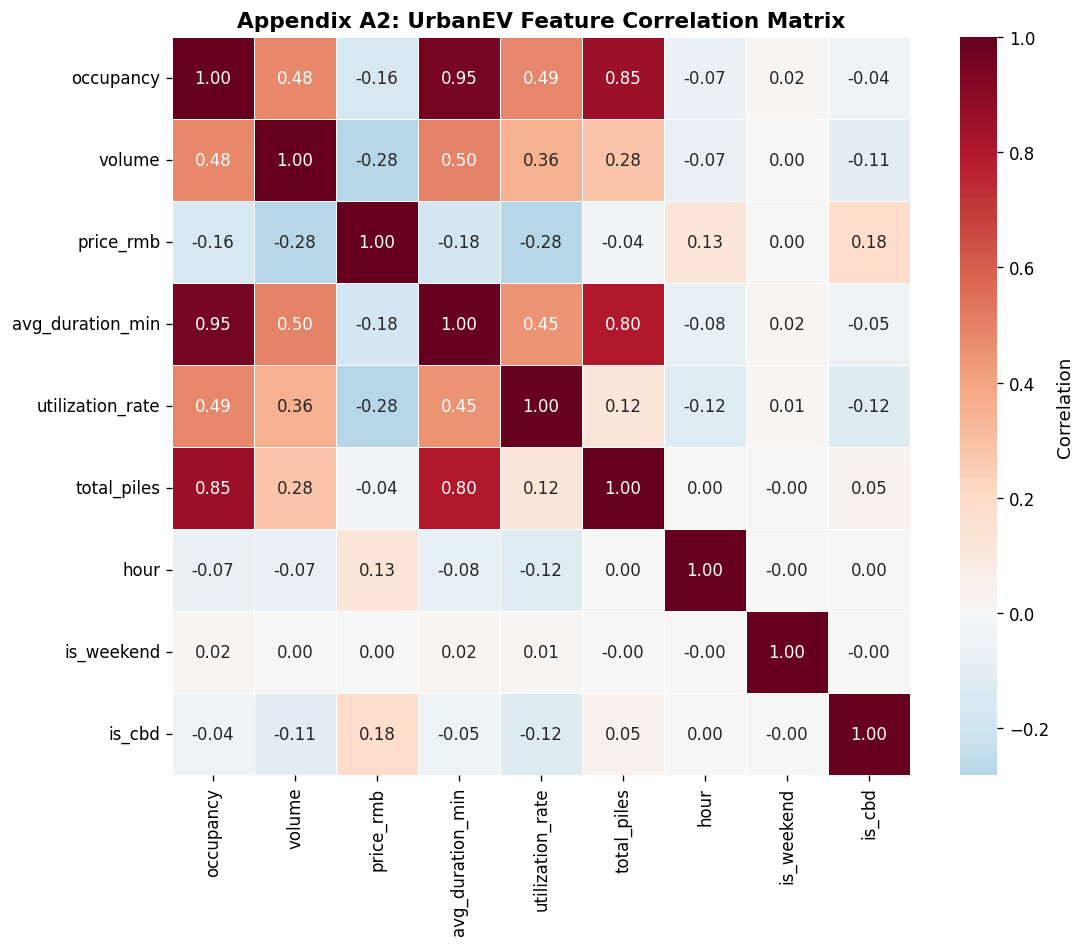

In [26]:
# A2: Correlation matrix — UrbanEV key features
corr_cols = ['occupancy','volume','price_rmb','avg_duration_min',
             'utilization_rate','total_piles','hour','is_weekend','is_cbd']
corr = ml_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True, cbar_kws={'label': 'Correlation'})
ax.set_title('Appendix A2: UrbanEV Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ev_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

Libraries loaded successfully 


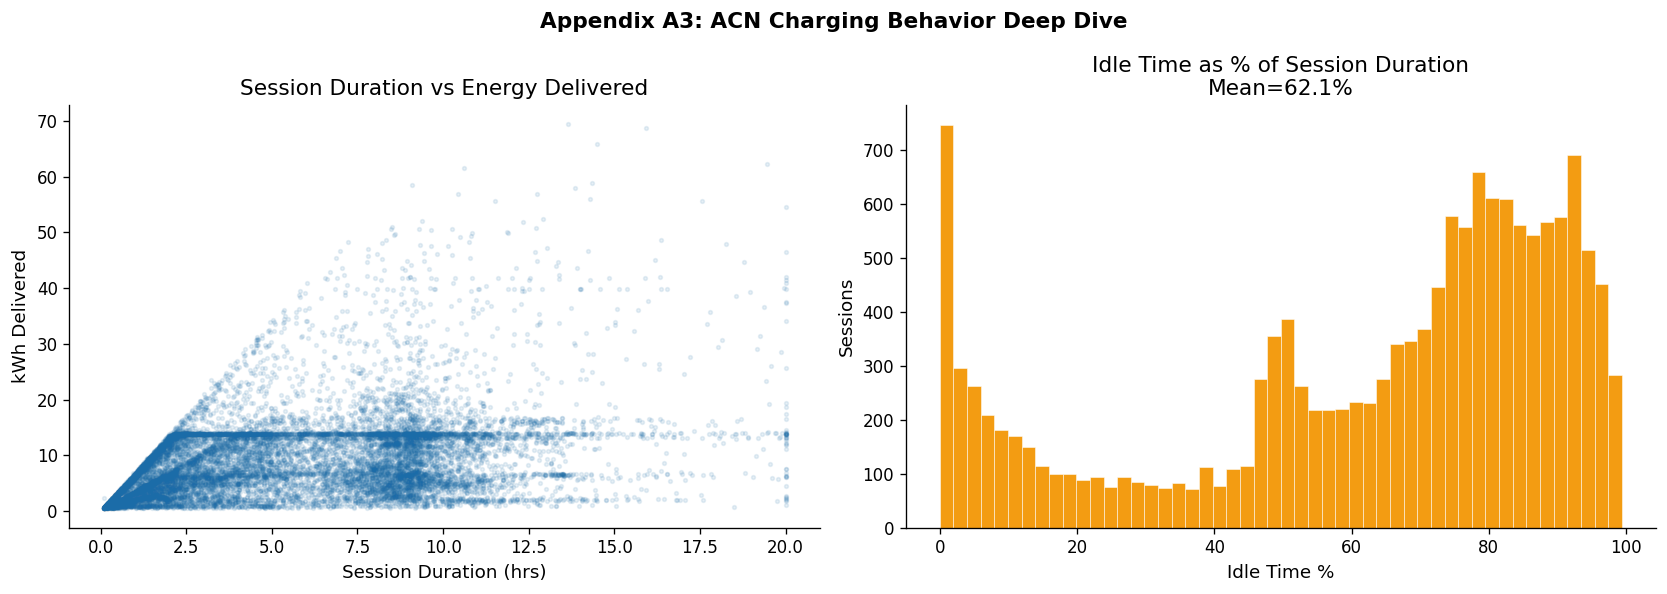


 High idle time (parked after charging) indicates opportunity for idle-time fees to free chargers.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, os, json , subprocess
from datetime import datetime, timedelta

from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})
COLOR_PALETTE = ['#1B6CA8', '#E05C2A', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C']
sns.set_palette(COLOR_PALETTE)

def time_bucket(h):
    if 7 <= h <= 9:   return 'morning_peak'
    if 17 <= h <= 19: return 'evening_peak'
    if 10 <= h <= 16: return 'midday'
    if 20 <= h <= 23: return 'night'
    return 'off_peak'

print('Libraries loaded successfully ')
# A3: ACN Session Duration vs kWh (Charging Efficiency)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Appendix A3: ACN Charging Behavior Deep Dive', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(acn['session_duration_hrs'].clip(0, 20), acn['kWhDelivered'],
           alpha=0.1, color=COLOR_PALETTE[0], s=5)
ax.set_xlabel('Session Duration (hrs)'); ax.set_ylabel('kWh Delivered')
ax.set_title('Session Duration vs Energy Delivered')

ax = axes[1]
idle_pct = acn['idle_time_hrs'] / acn['session_duration_hrs'].clip(lower=0.01) * 100
ax.hist(idle_pct.clip(0, 100), bins=50, color=COLOR_PALETTE[3], edgecolor='white', linewidth=0.3)
ax.set_xlabel('Idle Time %'); ax.set_ylabel('Sessions')
ax.set_title(f'Idle Time as % of Session Duration\nMean={idle_pct.mean():.1f}%')

plt.tight_layout()
plt.savefig('acn_charging_behavior.png', bbox_inches='tight', dpi=150)
plt.show()
print()
print(' High idle time (parked after charging) indicates opportunity for idle-time fees to free chargers.')